# **BAIT509 Final Project**

**Disclaimer** <br>
We used ChatGPT 5.2 as a coding assistant to help draft and debug Python code for data preprocessing, visualization, and feature importance extraction as well as to gain questions on specific functions and parameter trade-off for tree-based models. ChatGPT 5.2 is a suitable choice because it code suggestion and explanation are often based on common programming conventions, which allows us with faster iterations across models and improves consistency across script. However, we reviewed and adapted such generated code to our dataset. Other modeling decisions, analysis, and written interpretation were completed by the team.

# **Table of Content**
- Proposal
- Initial analysis
- Extended models
- Appendix


# **Proposal**

1. **What is your proposed business idea / product / tool? Who are the stakeholders and intended users, and what will they use it for? What information / features will they have available at prediction time?**

We propose to build a resolution-time estimation tool for the City of Vancouver’s 3-1-1 service request system. The tool is designed primarily for citizens who submit service requests and want to know the estimated completion time for their request. By providing an estimated resolution time based on factors such as request type, local area, department in charge, and communication channel, the tool improves transparency and reduces uncertainty, frustration, and repeated follow-up inquiries caused by unclear waiting periods.

In addition to public-facing benefits, the City government and internal departments can use the tool to evaluate operational efficiency. By comparing predicted and actual resolution times across departments, request types, and neighborhoods. The City can identify systematic delays, workload imbalances, and potential service inequities. These insights can support data-driven decisions related to staffing, workflow design, and performance benchmarking. Eventually, this tool could allow the City to identify gaps in resources that cause bottlenecks, and better optimize exisiting resources.

For prediction time, we are using the following information: the department responsible for the request, the service request type, the local area, the communication channel used, and the potential closure reason.

2. **What is the supervised learning problem that you want to solve for your business proposal? What are the features you want to use and the outcome you will predict?**

This project is formulated as a supervised regression problem. The goal is to predict the resolution time of a 3-1-1 service request in order to improve clarity and accountability between city departments and citizens, thereby reducing unnecessary waiting and uncertainty.

We plan to use input features such as department, service request type, local area, communication channel, and potential closure reason to train the model, which would them help us predict our outcome variable. The outcome variable is the resolution time, which is defined as the time difference between when a service request is opened and when it is last modified or closed.

3. **What real-world criteria will you use to define whether or not your proof of concept is successful? Be as precise as possible – e.g., dollars saved, human labor saved, return on investment, positive or negative cases identified, etc. We have not covered metrics, but if there are specific metrics you would like to target this will help this more concrete.**

The proof of concept will be considered successful if it leads to improvements in both predictive accuracy and operational usefulness. One key criterion is the ability to predict resolution times within a reasonable tolerance, such as having at least a specified percentage of requests predicted within plus or minus 24 hours of the actual resolution time, or achieving a mean absolute error below a defined threshold.

From an operational perspective, success can also be measured by improvements relative to existing baselines, such as an increase in on-time resolutions or a reduction in unexpected delays. On the citizen-facing side, improved transparency may lead to higher satisfaction with government services, which could be reflected in higher trust and citizen satisfaction, or fewer repeat inquiries for the same request. Even in the absence of direct financial metrics, these indicators provide concrete evidence of value.

4. **What dataset will you use? How does it support the goals of your project, and what are its limitations?**

- Dataset link: https://opendata.vancouver.ca/explore/dataset/3-1-1-service-requests/table/?disjunctive.service_request_type&disjunctive.status&disjunctive.channel&disjunctive.local_area&disjunctive.department&disjunctive.closure_reason

The dataset used in this project comes from the City of Vancouver Open Data Portal and consists of records from the City’s 3-1-1 case management system. It contains detailed information about service requests, including department, service request type, status, closure reason, service request open time, close date, last modified time, communication channel, and location-related attributes, making it well suited for building a supervised learning model to predict resolution time.

However, the dataset has several limitations. Some records are missing address, latitude, or longitude information, which restricts fine-grained spatial analysis. In addition, the available data only covers the period from 2022 to the present, limiting the ability to capture long-term trends or rare events. External factors such as weather conditions, staffing levels, or major city events are also not included and may influence resolution times in practice.

5. **What methods and analysis do you plan to perform? Feature generation, models to try, interpretation, etc. This is primarily for you to receive feedback.**

The analysis will begin with data cleaning and feature engineering, including computing resolution time from timestamps, extracting time-based features, encoding categorical variables, and handling missing data appropriately. Exploratory data analysis will be used to examine the distribution of resolution times and identify differences across departments, channel, request types, local areas.

For modeling, a linear regression approach will be used as a baseline to predict resolution time. Regularized versions of linear models, such as Ridge or Lasso regression, may be explored to address multicollinearity and improve generalization. Model interpretation will focus on understanding which features are most strongly associated with longer or shorter resolution times, providing insights that are actionable for both citizens and city administrators. Beyond linear regression, we may look into random forest model to better train our model for increased prediction accuracy.


# **Initial Analysis**

**Data loading & cleaning** <br>

Before performing the initial analysis, we load the raw 3-1-1 dataset and apply systematic cleaning and feature engineering steps. This ensures consistent category values, valid timestamps, and a reliable outcome variable for downstream analysis.

**Key steps performed below include:** <br>
- Standardize string fields & category names
- Handle missing geographic information
- Parse timestamps and converting them to Vancouver local time
- Construct the outcome variable (resolution time)
- Create flag columns for missing data & data-quality issues
- Converting some columns to lowercase

**Plot the distributions of features and outcomes in your dataset.** <br>

We plotted the distribution for five of the features that we were interested in and our outcome. We looked at the top 15 categories in each feature and grouped the "rare" categories as 'Other.' Please note, that since we grouped it together, for some of the distributions, the 'Other' category has the highest values. For example, the distribution for Request Type, shows the highest number of request type as 'Other', but this can be ignored as it is a group of different categories. Potentially, during our final analysis, we could look at the Top 20-25 categories and group the remainder to reduce the impact of 'Other'.

Additionally, for our outcome variable, we noticed that the distribution was highly skewed to the right, which highlights that most requests are completed in a short period of time, and it is hard to distinguish between those that take much longer. Hence, we did a Log transformation so our linear model can better understand the trends, and improve predictions.

Please find our distributions below!

**Identify at least 5 features that you expect to be useful in predicting your outcome. Implement appropriate preprocessing steps for these features.** <br>

We selected the following features:


*   Department
*   Request Type
*   Closure Reason
*   Local Area
*   Channel


Our outcome is **Resolution Time.**

Please view our pre-processing steps below.



**Train a linear model (linear or logistic regression) for your prediction problem using the features that you have chosen.** <br>

Please find out linear model below, where we have explained the process step-by-step.

**Data Pre-processing**

In [ ]:
import os
os.environ["PYTHONHASHSEED"] = "42"

SEED = 42

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Choose file

INPUT_PATH = "3-1-1-service-requests.csv"   # <-- replace with your actual filename

OUT_DIR = os.path.dirname(INPUT_PATH)
CLEAN_PATH = os.path.join(OUT_DIR, "311_cleaned_for_model.csv")

SAMPLE_N = 200000   # set None to use full dataset
TOP_K = 20
FMT = "%d %m %y %H:%M"

# Read CSV (auto sep)
def read_csv_auto_sep(path: str):
    for sep in [";", ","]:
        try:
            tmp = pd.read_csv(path, sep=sep, dtype=str, encoding="utf-8", engine="python")
            if tmp.shape[1] >= 8:
                print(f"[OK] Loaded with sep='{sep}' | shape={tmp.shape}")
                return tmp, sep
        except Exception:
            continue
    raise ValueError("Could not detect separator.")

df, SEP = read_csv_auto_sep(INPUT_PATH)
df.columns = [c.strip() for c in df.columns]


# Basic string cleaning
def clean_str_series(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.mask(s.isna() | (s == ""), pd.NA)
    return s

for c in df.columns:
    df[c] = clean_str_series(df[c])

# Keep only columns we need
BASE_COLS = [
    "Department", "Service request type", "Closure reason", "Local area", "Channel",
    "Service request open timestamp", "Service request close date", "Last modified timestamp",
    "Address", "Latitude", "Longitude", "geom"
]
df = df[BASE_COLS].copy()

# Optional sample
if SAMPLE_N is not None and len(df) > SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)
    print(f"[INFO] Sampled {SAMPLE_N} rows.")


# Normalize categories
def normalize_text(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.replace("–", "-", regex=False).str.replace("—", "-", regex=False)
    s = s.str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    s = s.mask(s.isna() | (s == ""), pd.NA)
    return s

def normalize_channel(s: pd.Series) -> pd.Series:
    s = normalize_text(s).str.lower()
    mapping = {
        "web": "web", "www": "web", "online": "web",
        "mobile app": "mobile app", "app": "mobile app",
        "phone": "phone", "telephone": "phone",
    }
    return s.map(lambda x: mapping.get(x, x) if pd.notna(x) else x)

df["Department"] = normalize_text(df["Department"])
df["Service request type"] = normalize_text(df["Service request type"])
df["Closure reason"] = normalize_text(df["Closure reason"])
df["Local area"] = normalize_text(df["Local area"])
df["Channel"] = normalize_channel(df["Channel"])

# Convert text to lowercase
df["Service request type"] = normalize_text(df["Service request type"]).str.lower()
df["Closure reason"] = normalize_text(df["Closure reason"]).str.lower()

# Department split
dep = df["Department"].astype("string")
df["dept_lang"] = dep.str.extract(r"^([A-Za-z]{2,3})\s*-\s*(.*)$")[0]
df["dept_name"] = dep.str.extract(r"^([A-Za-z]{2,3})\s*-\s*(.*)$")[1].fillna(dep).str.lower()
df["request_type_norm"] = df["Service request type"].astype("string").str.lower()

# Missing flags + fill 0 for area-related
area_cols = ["Address", "Local area", "Latitude", "Longitude", "geom"]
df["area_was_missing_flag"] = df[area_cols].isna().any(axis=1).astype(int)

df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

# Fill lat/lon from geom if possible
g = df["geom"].astype("string").fillna("")
g2 = g.str.replace(r"[\t,]+", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
geom_lat = pd.to_numeric(g2.str.split(" ").str[0], errors="coerce")
geom_lon = pd.to_numeric(g2.str.split(" ").str[1], errors="coerce")

df.loc[df["Latitude"].isna(), "Latitude"] = geom_lat[df["Latitude"].isna()]
df.loc[df["Longitude"].isna(), "Longitude"] = geom_lon[df["Longitude"].isna()]

df["Address"] = df["Address"].fillna("0")
df["Local area"] = df["Local area"].fillna("0")
df["geom"] = df["geom"].fillna("0")
df["Latitude"] = df["Latitude"].fillna(0.0)
df["Longitude"] = df["Longitude"].fillna(0.0)

# Robust time parsing (UTC -> Vancouver)
# Close date - alternative column: interpret as Vancouver date END-OF-DAY (23:59:59)
def parse_utc(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)

def to_vancouver_naive(dt_utc: pd.Series) -> pd.Series:
    return dt_utc.dt.tz_convert("America/Vancouver").dt.tz_localize(None)

open_utc = parse_utc(df["Service request open timestamp"])
lastmod_utc = parse_utc(df["Last modified timestamp"])

df["open_time_local"] = to_vancouver_naive(open_utc)
df["lastmod_time_local"] = to_vancouver_naive(lastmod_utc)

close_date_naive = pd.to_datetime(df["Service request close date"], errors="coerce")
df["close_time_local_eod"] = close_date_naive + pd.to_timedelta(23, "h") + pd.to_timedelta(59, "m") + pd.to_timedelta(59, "s")

df["resolve_time_local"] = df["lastmod_time_local"].combine_first(df["close_time_local_eod"])

df["resolve_before_open_flag"] = (
    df["resolve_time_local"].notna() &
    df["open_time_local"].notna() &
    (df["resolve_time_local"] < df["open_time_local"])
).astype(int)

df["resolution_minutes"] = (df["resolve_time_local"] - df["open_time_local"]).dt.total_seconds() / 60.0
df["resolution_hours"] = df["resolution_minutes"] / 60.0

neg = df["resolution_minutes"].notna() & (df["resolution_minutes"] < 0)
df.loc[neg, ["resolution_minutes", "resolution_hours"]] = np.nan

df["resolution_log1p_minutes"] = np.log1p(df["resolution_minutes"])

print("[INFO] negative outcomes set NaN:", int(neg.sum()))
print("[INFO] resolve_before_open_flag:", int(df["resolve_before_open_flag"].sum()))

# Create dataframe
model_df = df[[
    "dept_name", "request_type_norm", "Closure reason", "Local area", "Channel",
    "resolution_minutes", "resolution_log1p_minutes",
    "area_was_missing_flag", "resolve_before_open_flag"
]].copy()

for col in ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]:
    model_df[col] = model_df[col].fillna("unknown")


[OK] Loaded with sep=';' | shape=(1104165, 13)
[INFO] Sampled 200000 rows.
[INFO] negative outcomes set NaN: 24
[INFO] resolve_before_open_flag: 24


**Distributions**

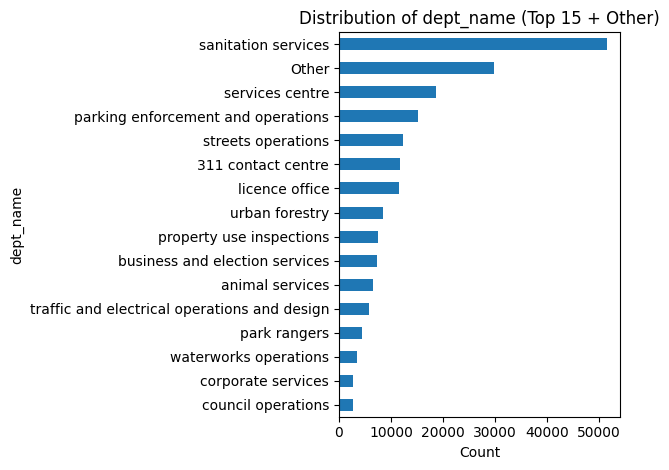

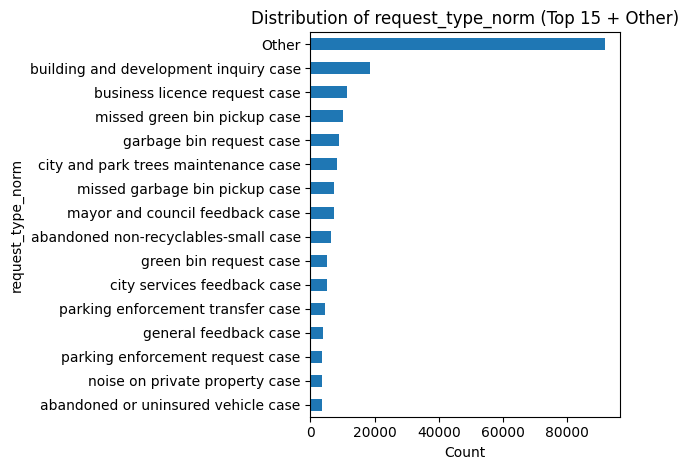

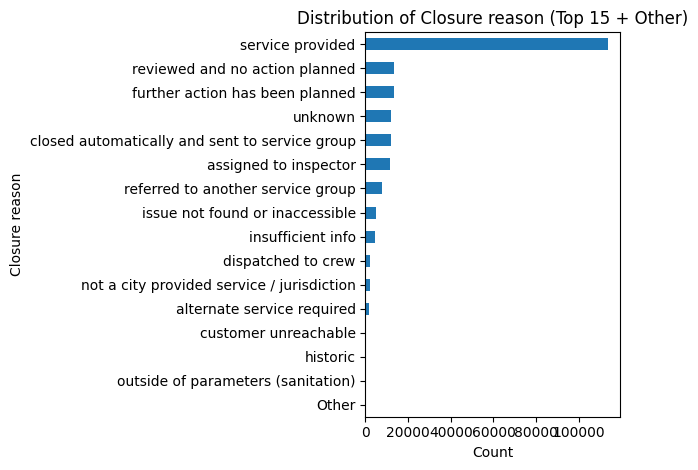

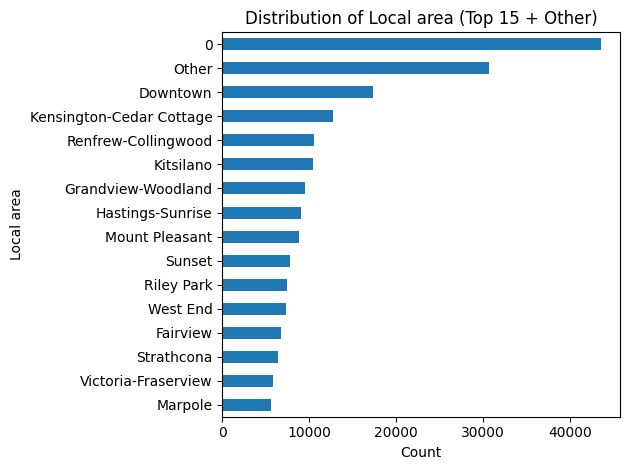

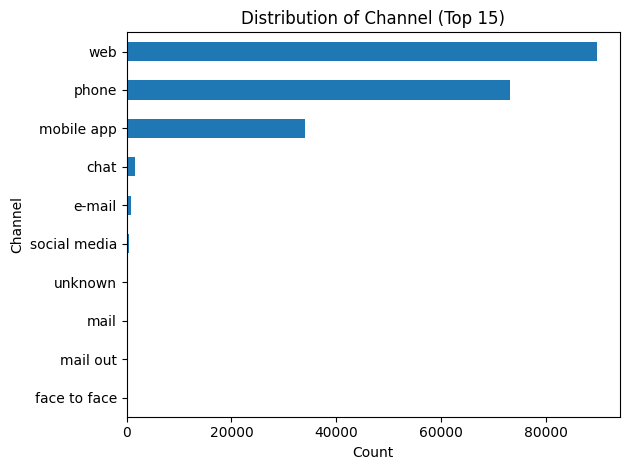

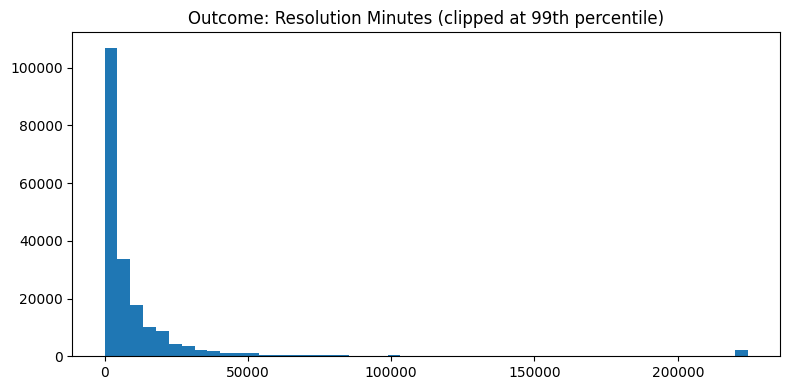

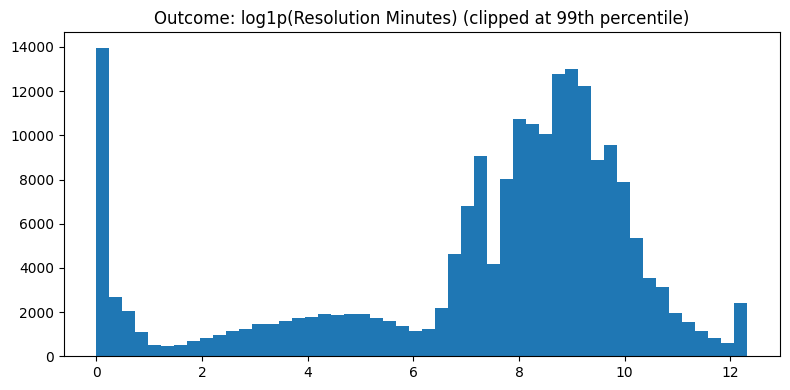

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#path = "/content/311_cleaned_for_model.csv"
#df = pd.read_csv(path, sep=";")

features = [
    "dept_name", # Changed from "Department"
    "request_type_norm", # Changed from "Service request type"
    "Closure reason",
    "Local area",
    "Channel",
]

def plot_categorical_distribution(
    data: pd.DataFrame,
    col: str,
    top_n: int = 15,
    include_missing: bool = True
):
    s = data[col].copy()

    if include_missing:
        s = s.fillna("Missing")
    else:
        s = s.dropna()

    counts = s.value_counts(dropna=False)

    if len(counts) > top_n:
        top = counts.iloc[:top_n]
        other_sum = counts.iloc[top_n:].sum()
        counts_to_plot = top.copy()
        if other_sum > 0:
            counts_to_plot.loc["Other"] = other_sum
    else:
        counts_to_plot = counts

    plt.figure()
    counts_to_plot.sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Distribution of {col} (Top {top_n}" + (" + Other" if len(counts) > top_n else "") + ")")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

for c in features:
    plot_categorical_distribution(model_df, c, top_n=15, include_missing=True) # Changed `df` to `model_df`

# Outcome distributions (optional)
plt.figure(figsize=(8, 4))
plt.hist(model_df["resolution_minutes"].clip(upper=model_df["resolution_minutes"].quantile(0.99)), bins=50)
plt.title("Outcome: Resolution Minutes (clipped at 99th percentile)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(model_df["resolution_log1p_minutes"].clip(upper=model_df["resolution_log1p_minutes"].quantile(0.99)), bins=50)
plt.title("Outcome: log1p(Resolution Minutes) (clipped at 99th percentile)")
plt.tight_layout()
plt.show()


**Linear Model** <br>
1. Extract dataframe for modelling

In [ ]:
model_df2 = df[[
    "dept_name", "request_type_norm", "Closure reason", "Local area", "Channel",
    "resolution_minutes", "resolution_log1p_minutes",
    "area_was_missing_flag", "resolve_before_open_flag", "Longitude", "Latitude"
]].copy()

for col in ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel", "Longitude", "Latitude"]:
    model_df2[col] = model_df2[col].fillna("unknown")

before2 = len(model_df2)
model_df2 = model_df2.dropna(subset=["resolution_minutes"]).reset_index(drop=True)
after2 = len(model_df2)
print(f"[INFO] rows before/after drop missing outcome: {before2} -> {after2}")

model_df2.to_csv("311_cleaned_with_latlon.csv", index=False, encoding="utf-8-sig")
print("Saved:", "311_cleaned_with_latlon.csv")

[INFO] rows before/after drop missing outcome: 200000 -> 199976
Saved: 311_cleaned_with_latlon.csv


2. Check outcome statistics <br>

- Actual resolution time is very **right-skewed**, with a long tail of extreme cases lasting from  months to years. This motivates us to use lograithmic transformation for the outcome values for modelling.

- Although the longest resolution time exceeds **more than 3 years**, the majority of service requests were resolved much faster, showing that not all service requests have the same level of complexity.

- The **median** resolution time is **~ 2.8 days**, which means that more than half of all requests are completed within a few days. Meanwhile, its mean (10.9 days) is about four times of the median, which is likely due to outlier cases.

- **75% of service requests** are resolved **under 8 days**, suggesting that most of our requests are of short/medium duration.

In [ ]:
# Basic stats
stats = model_df2["resolution_minutes"].describe()

# Combine minutes and days side by side
stats_table = pd.DataFrame({
    "Minutes": stats.apply(lambda x: f"{x:,.0f}"),
    "Days": (stats / (60 * 24)).round(2)
})

print("=== Resolution Time Summary ===")
display(stats_table)


=== Resolution Time Summary ===


,Minutes,Days
count,"199,976",138.87
mean,"15,677",10.89
std,"68,978",47.90
min,0,0.00
25%,704,0.49
50%,"4,061",2.82
75%,"11,206",7.78
max,"1,754,828",1218.63


3. Check # unique values for each feature & idea for transformation

In [ ]:
import pandas as pd

cols = ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel", "Longitude", "Latitude"]

# Define our next steps
next_step_map = {
    "dept_name": "One-hot encode",
    "request_type_norm": "Feature hashing",
    "Closure reason": "One-hot encode",
    "Local area": "One-hot encode",
    "Channel": "One-hot encode",
    "Longitude": "Spatial binning (KBins)",
    "Latitude": "Spatial binning (KBins)",
}

rationale_map = {
    "dept_name": "Categorical; departments may have different workflows/SLAs.",
    "request_type_norm": "High-cardinality text-like category; hashing keeps feature size manageable.",
    "Closure reason": "Categorical outcome context; may correlate with resolution process length.",
    "Local area": "Geography proxy; one-hot works if not too many unique areas; group rare if needed.",
    "Channel": "Request intake channel can impact processing speed and routing.",
    "Longitude": "Continuous; bin to capture coarse location effects without overfitting.",
    "Latitude": "Continuous; bin to capture coarse location effects without overfitting.",
}

# Build table
rows = []
for c in cols:
    rows.append({
        "Feature": c,
        "Unique values": model_df2[c].nunique(dropna=False),
        "Next step": next_step_map.get(c, ""),
        "Rationale": rationale_map.get(c, "")})

feature_plan = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", None)

feature_plan.style.set_properties(
    **{"white-space": "pre-wrap"})

display(feature_plan)


,Feature,Unique values,Next step,Rationale
0,dept_name,68,One-hot encode,Categorical; departments may have different workflows/SLAs.
1,request_type_norm,243,Feature hashing,High-cardinality text-like category; hashing keeps feature size manageable.
2,Closure reason,16,One-hot encode,Categorical outcome context; may correlate with resolution process length.
3,Local area,23,One-hot encode,Geography proxy; one-hot works if not too many unique areas; group rare if needed.
4,Channel,10,One-hot encode,Request intake channel can impact processing speed and routing.
5,Longitude,50966,Spatial binning (KBins),Continuous; bin to capture coarse location effects without overfitting.
6,Latitude,50186,Spatial binning (KBins),Continuous; bin to capture coarse location effects without overfitting.


4. Split data set <br>
We randomly divide the data into training (80%) and testing (20%) subsets. The training set will be used to fit the model, while the test set is for evaluating the model performance.

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df2[
    [   "dept_name",
        "request_type_norm",
        "Closure reason",
        "Local area",
        "Channel",
        "Latitude",
        "Longitude",]]

y = model_df2["resolution_log1p_minutes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


5. Create data pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer, PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

onehot_features = ["dept_name", "Closure reason", "Local area", "Channel"]

onehot_encoder = OneHotEncoder(handle_unknown="ignore")

hash_pipe = make_pipeline(
    FunctionTransformer(
        lambda s: s.fillna("unknown").astype(str).apply(lambda x: {x: 1}),
        validate=False
    ),
    FeatureHasher(n_features=128, input_type="dict"))

grid_pipeline = make_pipeline(
    KBinsDiscretizer(n_bins=10, encode="onehot", strategy="quantile"),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    VarianceThreshold(0.0))

transformer = ColumnTransformer(
    transformers=[
        ("onehot", onehot_encoder, onehot_features),
        ("hash", hash_pipe, "request_type_norm"),
        ("grid", grid_pipeline, ["Latitude", "Longitude"]),
    ], remainder="drop")

6. Fit transformer on training data; transform train/test

In [ ]:
xtr_trans = transformer.fit_transform(X_train)
xte_trans = transformer.transform(X_test)

print("Train shape:", xtr_trans.shape)
print("Test shape:", xte_trans.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Train shape: (159980, 269)
Test shape: (39996, 269)


7. Fit linear model & evaluation <br>

The model can explain **~67% of data variance.** We also tried a linear model (see in appendix) without longitude and latitude data, which had the same amount of data variance, hence, those features are not influncing our forecasting.
<br>

Our predictions focused primarily within the **0–30 day** range, meaning most 3-1-1 service requests are resolved within a relatively short time period. Predicted resolution times rarely exceed 50 days, even when actual outcomes go substantially beyond it. Along the red line, predictions are **most accurate** for **short & medium duration requests**, which contribute the most to our dataset and represent the primary operational workload faced by the city.

Overall, the model tends to **under-predict** cases with very **long resolution times**. Requests that ultimately remain open for months or years are often predicted as moderate-duration cases. This is expected given the strong right-skewness of the outcome variable, where a small number of outlier cases influence the fitted regression despite our log transformation.

Our linear model is better suited to estimate the **typical resolution duration**, rather than extreme backlog cases.

The distribution of resolution time remains **heavily right-tailed** even after applying a log1p transformation. While the transformation improves numerical stability and model fit, it does not eliminate the structural heterogeneity inherent in operational processes. Thus, prediction errors increase as actual resolution time grows, resulting in greater dispersion in the upper tail of the below graph. We would interested in using other ML models such as Random Forest, to see if it improves our predictions.

In [ ]:
# Accuracy measures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(xtr_trans, y_train)

pred = model.predict(xte_trans)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Predicted vs Actual Graph
# Predict log resolution time
pred_log = model.predict(xte_trans)

# Convert back to minutes
pred_minutes = np.expm1(pred_log)
actual_minutes = np.expm1(y_test)

# Convert from minutes to days
pred_days = pred_minutes / (60 * 24)
actual_days = actual_minutes / (60 * 24)

# Build dataframe
predictions_df = pd.concat(
    (
        X_test.reset_index(drop=True),
        pd.DataFrame(
            {
                "Actual Resolution (days)": actual_days.values,
                "Predicted Resolution (days)": pred_days,
            }), ), axis=1,)

# Sample for plotting
plot_df = predictions_df.sample(n=5000, random_state=42)

import altair as alt

scatter = (
    alt.Chart(plot_df)
    .mark_circle(opacity=0.4, size=30)
    .encode(
        x=alt.X(
            "Predicted Resolution (days):Q",
            title="Predicted Resolution Time (days)"),
        y=alt.Y(
            "Actual Resolution (days):Q",
            title="Actual Resolution Time (days)"),
        tooltip=[
            "Actual Resolution (days):Q",
            "Predicted Resolution (days):Q"
        ],))

# Diagonal reference line (perfect prediction)
min_val = min(
    plot_df["Actual Resolution (days)"].min(),
    plot_df["Predicted Resolution (days)"].min(),)

max_val = max(
    plot_df["Actual Resolution (days)"].max(),
    plot_df["Predicted Resolution (days)"].max(),)

diagonal_df = pd.DataFrame(
    {"x": [min_val, max_val], "y": [min_val, max_val]})

diagonal = (
    alt.Chart(diagonal_df)
    .mark_line(color="red", strokeDash=[5, 5])
    .encode(x="x:Q", y="y:Q"))

(scatter + diagonal).properties(
    title="Actual vs Predicted Resolution Time (Days)",
    width=600,
    height=600,)

MAE: 1.2720670571105621
RMSE: 1.7947939284121364
R²: 0.6720748469236586


alt.LayerChart(...)

**Compare train vs test losses**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Predictions
pred_train = model.predict(xtr_trans)
pred_test  = model.predict(xte_trans)

# Loss/fit metrics (on log1p minutes, same target you trained on)
metrics = pd.DataFrame({
    "Split": ["Train", "Test"],
    "MAE": [
        mean_absolute_error(y_train, pred_train),
        mean_absolute_error(y_test,  pred_test),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, pred_train)),
        np.sqrt(mean_squared_error(y_test,  pred_test)),
    ],
    "R2": [
        r2_score(y_train, pred_train),
        r2_score(y_test,  pred_test),
    ],
})

display(metrics)

# Optional: also show MAE/RMSE back in minutes space (can be more interpretable, but nonlinear)
pred_train_min = np.expm1(pred_train)
pred_test_min  = np.expm1(pred_test)
y_train_min    = np.expm1(y_train)
y_test_min     = np.expm1(y_test)

metrics_minutes = pd.DataFrame({
    "Split": ["Train", "Test"],
    "MAE_minutes": [
        mean_absolute_error(y_train_min, pred_train_min),
        mean_absolute_error(y_test_min,  pred_test_min),
    ],
    "RMSE_minutes": [
        np.sqrt(mean_squared_error(y_train_min, pred_train_min)),
        np.sqrt(mean_squared_error(y_test_min,  pred_test_min)),
    ],
})

display(metrics_minutes)

,Split,MAE,RMSE,R2
0,Train,1.265147,1.783885,0.672675
1,Test,1.272067,1.794794,0.672075


,Split,MAE_minutes,RMSE_minutes
0,Train,13283.065523,68193.489161
1,Test,13780.646132,71653.151892


**Feature importance**

Below are the top 30 most impactful coefficients from all transformed features used in the baseline linear regression model. As each original variable is expanded into many encoded columns through one-hot encoding, feature hashing, and spatial binning with polynomial interactions, we also reported the aggregate-level of these coefficients by key feature groups i.e., categorical attributes, request type, and spatial location. Specifically, we summed the absolute of all relevant component features within each group. This provides an interpretable, high-level view of how each feature type contributes to the model predictions.

In [ ]:
import numpy as np
import pandas as pd

# ---- Build feature names in the same order as ColumnTransformer outputs ----
feature_names = []

# (A) One-hot block
ohe = transformer.named_transformers_["onehot"]
ohe_names = ohe.get_feature_names_out(onehot_features)
feature_names.extend(ohe_names)

# (B) Hash block (FeatureHasher) -> names are just hash bins
n_hash = transformer.named_transformers_["hash"].named_steps["featurehasher"].n_features
feature_names.extend([f"hash_request_type_bin_{i}" for i in range(n_hash)])

# (C) Grid block (KBins -> Poly interactions -> VarianceThreshold)
grid_pipe = transformer.named_transformers_["grid"]
kbins = grid_pipe.named_steps["kbinsdiscretizer"]
poly  = grid_pipe.named_steps["polynomialfeatures"]
vt    = grid_pipe.named_steps["variancethreshold"]

# KBins output feature names
try:
    kbins_names = kbins.get_feature_names_out(["Latitude", "Longitude"])
except Exception:
    kbins_names = [
        f"grid_bin_{i}"
        for i in range(kbins.transform(X_train[["Latitude","Longitude"]]).shape[1])
    ]

# Polynomial feature names
poly_names = poly.get_feature_names_out(kbins_names)

# Apply VarianceThreshold mask
mask = vt.get_support()
grid_names = np.array(poly_names)[mask]
feature_names.extend(list(grid_names))

# ---- Align with coefficients ----
coefs = model.coef_.ravel()

if len(feature_names) != len(coefs):
    print(f"[WARN] feature_names ({len(feature_names)}) != coef ({len(coefs)}). Using index-based names.")
    feature_names = [f"feature_{i}" for i in range(len(coefs))]

# ---- Build importance table ----
imp = pd.DataFrame({
    "feature": feature_names,
    "coef": np.round(coefs, 2),
    "abs_coef": np.round(np.abs(coefs), 2)
}).sort_values("abs_coef", ascending=False)

# Show top 30 detailed features
display(imp.head(30))

# ---- Aggregated importance by feature group ----
imp["group"] = np.select(
    [
        imp["feature"].str.contains("dept_name_|Closure reason_|Local area_|Channel_"),
        imp["feature"].str.startswith("hash_request_type_bin_"),
    ],
    ["onehot_categoricals", "hashed_request_type"],
    default="latlon_grid_poly"
)

group_imp = (
    imp.groupby("group", as_index=False)["abs_coef"]
    .sum()
    .sort_values("abs_coef", ascending=False)
)

display(group_imp)


,feature,coef,abs_coef
55,dept_name_transit integrations and projects,6.73,6.73
38,dept_name_public space and street use,-6.68,6.68
36,dept_name_property tax,5.06,5.06
216,hash_request_type_bin_99,4.96,4.96
83,Closure reason_unknown,-4.79,4.79
195,hash_request_type_bin_78,-4.61,4.61
34,dept_name_planning and development,4.58,4.58
27,dept_name_neighbourhood energy branch,4.43,4.43
185,hash_request_type_bin_68,-4.32,4.32
236,hash_request_type_bin_119,-4.29,4.29


,group,abs_coef
2,onehot_categoricals,136.72
0,hashed_request_type,132.25
1,latlon_grid_poly,1.11


# **Extended models**

**Data classification overview**

In [ ]:
# By long/short class

import pandas as pd
import numpy as np

# ---- parameters (keep consistent with modeling) ----
SHORT_LONG_RULE = "p75"   # "median" | "p75" | "fixed_days"
FIXED_DAYS = 7

df_ls = model_df2.copy()

# ensure numeric + drop NA consistently
df_ls["resolution_minutes"] = pd.to_numeric(df_ls["resolution_minutes"], errors="coerce")
df_ls = df_ls.dropna(subset=["resolution_minutes"]).reset_index(drop=True)

# threshold
if SHORT_LONG_RULE == "median":
    thr_min = df_ls["resolution_minutes"].median()
    thr_label = "median"
elif SHORT_LONG_RULE == "p75":
    thr_min = df_ls["resolution_minutes"].quantile(0.75)
    thr_label = "p75"
elif SHORT_LONG_RULE == "fixed_days":
    thr_min = FIXED_DAYS * 24 * 60
    thr_label = f"{FIXED_DAYS}days"
else:
    raise ValueError("Invalid SHORT_LONG_RULE")

df_ls["short_long_class"] = np.where(
    df_ls["resolution_minutes"] <= thr_min, "short", "long"
)

# table
tbl_long_short = (
    df_ls["short_long_class"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

tbl_long_short["Percent (%)"] = (
    tbl_long_short["Count"] / tbl_long_short["Count"].sum() * 100
).round(2)

tbl_long_short = tbl_long_short.reset_index().rename(
    columns={"index": "Resolution class"}
)

print(tbl_long_short)

# By department

df_dept = model_df2.copy()

tbl_dept = (
    df_dept["dept_name"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

tbl_dept["Percent (%)"] = (
    tbl_dept["Count"] / tbl_dept["Count"].sum() * 100
).round(2)

tbl_dept = (
    tbl_dept
    .reset_index()
    .rename(columns={"index": "Department"})
    .sort_values("Count", ascending=False)
)

print(tbl_dept)

# By channel

df_chan = model_df2.copy()

# light normalization (if already normalized earlier, this is idempotent)
df_chan["Channel"] = (
    df_chan["Channel"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({"nan": "unknown", "": "unknown"})
    .fillna("unknown")
)

tbl_channel = (
    df_chan["Channel"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

tbl_channel["Percent (%)"] = (
    tbl_channel["Count"] / tbl_channel["Count"].sum() * 100
).round(2)

tbl_channel = (
    tbl_channel
    .reset_index()
    .rename(columns={"index": "Channel"})
    .sort_values("Count", ascending=False)
)

print(tbl_channel)



  short_long_class   Count  Percent (%)
0            short  149982         75.0
1             long   49994         25.0
                                             dept_name  Count  Percent (%)
0                                  sanitation services  51477        25.74
1                                      services centre  18607          9.3
2                   parking enforcement and operations  15286         7.64
3                                   streets operations  12409         6.21
4                                   311 contact centre  11794          5.9
..                                                 ...    ...          ...
63  accs - homelessness service and affordable housing     14         0.01
64                            accs - cultural services     11         0.01
65                         neighbourhood energy branch      9          0.0
66                         public space and street use      1          0.0
67                                  community services 

**Overview**


**Note**

First, we define evaluation helper functions that (i) train a model, (ii) make predictions, and (iii) compute consistent performance metrics (MAE, RMSE, R², days-based errors, and tolerance accuracy) so each model for each data split later is evaluated the same way.

Building on the baseline linear model, we removed spatial binning features that did not improve predictive accuracy and streamlined the preprocessing pipeline for stability and speed. This allowed us to focus on testing meaningful data splits and comparing linear and tree-based models under a consistent feature framework.

In [ ]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone


# 0) REQUIREMENTS CHECK

assert "resolution_log1p_minutes" in model_df2.columns, "model_df2 not found or missing outcome columns."
assert "dept_name" in model_df2.columns, "model_df2 missing dept_name."
assert "request_type_norm" in model_df2.columns, "model_df2 missing request_type_norm."


# 1) GLOBAL SETTINGS

SEED = 42
TEST_SIZE = 0.2

TOP_DEPTLANG_K = 8
MIN_GROUP_N = 2000

SHORT_LONG_RULE = "p75"     # "median" | "p75" | "fixed_days"
FIXED_DAYS = 7

HASH_D = 128


# 2) TRANSFORMER  (NO LAT/LONG, NO KBins)

onehot_features = ["dept_name", "Closure reason", "Local area", "Channel"]
onehot_encoder = OneHotEncoder(handle_unknown="ignore")

hash_pipe = make_pipeline(
    FunctionTransformer(
        lambda s: s.fillna("unknown").astype(str).apply(lambda x: {x: 1}),
        validate=False
    ),
    FeatureHasher(n_features=HASH_D, input_type="dict")
)

transformer = ColumnTransformer(
    transformers=[
        ("onehot", onehot_encoder, onehot_features),
        ("hash", hash_pipe, "request_type_norm"),
    ],
    remainder="drop"
)


# 3) MODELS

HAS_XGB = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    print("[WARN] xgboost not installed. XGBoost model will be skipped. Error:", str(e))

def get_models():
    models = {}

    models["LinearRegression"] = LinearRegression()

    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )

    # Consider lowering n_estimators if runtime is still heavy
    models["RandomForest"] = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED
    )

    return models


# 4) METRICS + EVAL HELPERS

def eval_regression(y_true_log, y_pred_log):
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2 = r2_score(y_true_log, y_pred_log)

    true_min = np.expm1(y_true_log)
    pred_min = np.expm1(y_pred_log)
    pred_min = np.maximum(pred_min, 0)

    ae_min = np.abs(true_min - pred_min)
    mae_min = ae_min.mean()
    rmse_min = np.sqrt(((true_min - pred_min) ** 2).mean())

    mae_days = mae_min / (60 * 24)
    rmse_days = rmse_min / (60 * 24)

    within_24h = (ae_min <= 24 * 60).mean()
    within_48h = (ae_min <= 48 * 60).mean()

    median_ae_days = np.median(ae_min) / (60 * 24)

    return {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2_log": r2,
        "MAE_days": mae_days,
        "RMSE_days": rmse_days,
        "Median_AE_days": median_ae_days,
        "Acc_within_24h": within_24h,
        "Acc_within_48h": within_48h
    }

def fit_predict_one_model(model_name, model_obj, X_train, X_test, y_train, y_test, transformer):
    """
    Fit transformer + model; handle RF dense conversion; return metrics dict.
    Uses clone(transformer) so each model gets a fresh unfitted preprocessor.
    """
    tfm = clone(transformer)

    Xtr = tfm.fit_transform(X_train)
    Xte = tfm.transform(X_test)

    if model_name == "RandomForest":
        # dense conversion can still be big, but should be smaller now (no lat/long bins)
        Xtr = Xtr.toarray()
        Xte = Xte.toarray()

    model_obj.fit(Xtr, y_train)
    pred = model_obj.predict(Xte)

    return eval_regression(y_test, pred)


def run_models_for_subset(df_sub, label, transformer, test_size=TEST_SIZE, seed=SEED):
    X = df_sub[["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]].copy()
    y = df_sub["resolution_log1p_minutes"].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    # ✅ Fit transformer ONCE per subset
    tfm = clone(transformer)
    t0 = time.time()
    Xtr = tfm.fit_transform(X_train)
    Xte = tfm.transform(X_test)
    print(f"[TIME] Preprocess {label}: {time.time()-t0:.1f}s | Xtr shape={Xtr.shape}")

    rows = []
    models = get_models()

    for mname, mobj in models.items():
        try:
            t1 = time.time()

            Xtr_use, Xte_use = Xtr, Xte
            if mname == "RandomForest":
                # RF needs dense -> expensive
                Xtr_use = Xtr.toarray()
                Xte_use = Xte.toarray()

            mobj.fit(Xtr_use, y_train)
            pred = mobj.predict(Xte_use)
            metrics = eval_regression(y_test, pred)

            print(f"[TIME] Model {label} | {mname}: {time.time()-t1:.1f}s")

            rows.append({
                "Split": label,
                "Model": mname,
                "N_train": len(X_train),
                "N_test": len(X_test),
                **metrics
            })

        except MemoryError:
            rows.append({
                "Split": label, "Model": mname, "N_train": len(X_train), "N_test": len(X_test),
                "ERROR": "MemoryError (RF dense matrix too large)"
            })
        except Exception as e:
            rows.append({
                "Split": label, "Model": mname, "N_train": len(X_train), "N_test": len(X_test),
                "ERROR": str(e)
            })

    res = pd.DataFrame(rows)
    metric_cols = ["MAE_log","RMSE_log","R2_log","MAE_days","RMSE_days","Median_AE_days","Acc_within_24h","Acc_within_48h"]
    keep_cols = ["Split","Model","N_train","N_test"] + [c for c in metric_cols if c in res.columns] + (["ERROR"] if "ERROR" in res.columns else [])
    return res[keep_cols].sort_values(["Split","Model"]).reset_index(drop=True)


def pretty_compare_table(results_df, sort_by="MAE_days"):
    df = results_df.copy()
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            if c.startswith("Acc_"):
                df[c] = (df[c] * 100).round(1)
            elif c == "R2_log":
                df[c] = df[c].round(3)
            else:
                df[c] = df[c].round(4)
    if sort_by in df.columns:
        df = df.sort_values(["Split", sort_by], ascending=[True, True]).reset_index(drop=True)
    return df


# **A. Extended models: By Long/Short Resolution Time** <br/>
Requests are segmented using a resolution-time threshold. Cases with resolution times above the 75th percentile (~8 days) are classified as long-time, while those at or below the threshold are classified as short-time.

**Split + preprocess for short & long type**

In [ ]:
from sklearn.base import clone

# A) PREP: build short/long labels + preprocess once per subset
df_base = model_df2.copy()

df_base["resolution_minutes"] = pd.to_numeric(df_base["resolution_minutes"], errors="coerce")
df_base["resolution_log1p_minutes"] = pd.to_numeric(df_base["resolution_log1p_minutes"], errors="coerce")
df_base = df_base.dropna(subset=["resolution_minutes", "resolution_log1p_minutes"]).reset_index(drop=True)

# threshold
if SHORT_LONG_RULE == "median":
    thr_min = df_base["resolution_minutes"].median()
    thr_label = "median"
elif SHORT_LONG_RULE == "p75":
    thr_min = df_base["resolution_minutes"].quantile(0.75)
    thr_label = "p75"
elif SHORT_LONG_RULE == "fixed_days":
    thr_min = FIXED_DAYS * 24 * 60
    thr_label = f"{FIXED_DAYS}days"
else:
    raise ValueError("SHORT_LONG_RULE must be 'median', 'p75', or 'fixed_days'.")

df_base["short_long_class"] = np.where(df_base["resolution_minutes"] <= thr_min, "short", "long")

print(f"[INFO] Short/Long threshold rule={thr_label} | threshold={thr_min/(60*24):.2f} days")
print(df_base["short_long_class"].value_counts(dropna=False))

# store preprocessed matrices here
cache = {}

FEATURES = ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]

for cls in ["short", "long"]:
    df_sub = df_base[df_base["short_long_class"] == cls].copy()
    if len(df_sub) < MIN_GROUP_N:
        print(f"[SKIP] short/long='{cls}' too small: n={len(df_sub)}")
        continue

    X = df_sub[FEATURES].copy()
    y = df_sub["resolution_log1p_minutes"].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )

    tfm = clone(transformer)
    Xtr = tfm.fit_transform(X_train)
    Xte = tfm.transform(X_test)

    cache[cls] = {
    "label": f"ShortLong={cls} (rule={thr_label})",
    "tfm": tfm,
    "Xtr": Xtr, "Xte": Xte,
    "ytr": y_train, "yte": y_test
}

    print(f"[OK] cached '{cls}': Xtr={Xtr.shape}, Xte={Xte.shape}")

[INFO] Short/Long threshold rule=p75 | threshold=7.78 days
short_long_class
short    149982
long      49994
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[OK] cached 'short': Xtr=(119985, 243), Xte=(29997, 243)
[OK] cached 'long': Xtr=(39995, 238), Xte=(9999, 238)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# **1. Linear regression (Long/Short)**

**1.1. Model results**

In [ ]:
from sklearn.linear_model import LinearRegression

rows = []
for cls, d in cache.items():
    m = LinearRegression()
    m.fit(d["Xtr"], d["ytr"])
    pred = m.predict(d["Xte"])
    metrics = eval_regression(d["yte"], pred)

    rows.append({"Split": d["label"], "Model": "LinearRegression", **metrics})

results_lin = pd.DataFrame(rows)
display(pretty_compare_table(results_lin, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),LinearRegression,0.5592,0.7763,0.231,26.5470,91.2280,6.3558,8.4,16.4
1,ShortLong=short (rule=p75),LinearRegression,1.1057,1.5632,0.728,1.3431,2.0919,0.7519,56.3,75.1


**1.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Linear Regression (Long vs Short)
#   1) return Top-K INTERPRETABLE features (exclude hash_*)
#   2) also return an aggregated "feature family" summary for stakeholder reporting
#   3) optionally save full output (incl. hash_*) for appendix

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def make_feature_names_for_lr(tfm, hash_dim=128):
    """
    Feature names aligned with your fitted ColumnTransformer:
      - onehot: dept_name, Closure reason, Local area, Channel
      - hash:  request_type_norm (FeatureHasher with fixed hash_dim)
    """
    names = []

    # OneHotEncoder names
    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # fallback: keep alignment if naming fails
            n_ohe = ohe.transform(
                pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
            ).shape[1]
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    # Hashed dims
    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    """Map raw feature names to stakeholder-friendly groups."""
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    # If you have other engineered features, add rules here
    return "Other"

# CONFIG
TOP_K_INTERPRETABLE = 10
TOP_K_FULL = 20
EXCLUDE_HASH_IN_MAIN = True

fi_all_rows = []          # full (incl hash)
fi_top_interp_rows = []   # top interpretable only
fi_group_rows = []        # aggregated by family

for cls, d in cache.items():
    tfm = d["tfm"]  # must be the SAME fitted ColumnTransformer used to create Xtr/Xte
    Xtr, ytr = d["Xtr"], d["ytr"]
    model = LinearRegression()
    model.fit(Xtr, ytr)

    feature_names = make_feature_names_for_lr(tfm, hash_dim=HASH_D)

    # sanity check
    assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

    coef = model.coef_.ravel()

    tmp = pd.DataFrame({
        "Split": d["label"],
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
    })
    tmp["group"] = tmp["feature"].apply(feature_group)

    # 1) FULL table (appendix)
    tmp_full = tmp.sort_values("abs_coef", ascending=False).head(TOP_K_FULL).copy()
    fi_all_rows.append(tmp_full)

    # 2) Top-K interpretable only (main report)
    tmp_interp = tmp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        tmp_interp = tmp_interp[~tmp_interp["feature"].str.startswith("hash_")]

    tmp_interp = tmp_interp.sort_values("abs_coef", ascending=False).head(TOP_K_INTERPRETABLE).copy()
    fi_top_interp_rows.append(tmp_interp)

    # 3) Aggregated by group (stakeholder summary)
    grp = (
        tmp.groupby(["Split", "group"], as_index=False)["abs_coef"]
           .sum()
           .rename(columns={"abs_coef": "total_abs_coef"})
    )
    # Optional: also compute share %
    grp["share"] = grp.groupby("Split")["total_abs_coef"].transform(lambda x: x / x.sum())
    grp = grp.sort_values(["Split", "total_abs_coef"], ascending=[True, False])
    fi_group_rows.append(grp)


# OUTPUT DATAFRAMES
feature_importance_lr_longshort_full_topk = pd.concat(fi_all_rows, ignore_index=True)
feature_importance_lr_longshort_top10_interpretable = pd.concat(fi_top_interp_rows, ignore_index=True)
feature_importance_lr_longshort_group_summary = pd.concat(fi_group_rows, ignore_index=True)

# Display (or save)
print("=== Top interpretable features (main report) ===")
display(feature_importance_lr_longshort_top10_interpretable)

print("=== Aggregated importance by feature family (stakeholder summary) ===")
display(feature_importance_lr_longshort_group_summary)

print("=== Top features incl. hash (appendix) ===")
display(feature_importance_lr_longshort_full_topk)

# Optional: save to CSV for report/appendix
# feature_importance_lr_longshort_top10_interpretable.to_csv("fi_lr_longshort_top10_interpretable.csv", index=False)
# feature_importance_lr_longshort_group_summary.to_csv("fi_lr_longshort_group_summary.csv", index=False)
# feature_importance_lr_longshort_full_topk.to_csv("fi_lr_longshort_full_topk.csv", index=False)

=== Top interpretable features (main report) ===


,Split,feature,coef,abs_coef,group
0,ShortLong=short (rule=p75),dept_name_street use management,-4.639379,4.639379,Department
1,ShortLong=short (rule=p75),dept_name_planning and development,4.430340,4.430340,Department
2,ShortLong=short (rule=p75),Closure reason_unknown,-4.333158,4.333158,Closure Reason
3,ShortLong=short (rule=p75),dept_name_transit integrations and projects,4.319915,4.319915,Department
4,ShortLong=short (rule=p75),dept_name_property tax,3.652971,3.652971,Department
5,ShortLong=short (rule=p75),dept_name_animal services,-3.077899,3.077899,Department
6,ShortLong=short (rule=p75),dept_name_neighbourhood energy branch,3.076047,3.076047,Department
7,ShortLong=short (rule=p75),dept_name_development and major projects branch,-2.965204,2.965204,Department
8,ShortLong=short (rule=p75),dept_name_integrated graffiti management,-2.874608,2.874608,Department
9,ShortLong=short (rule=p75),dept_name_accs - cultural services,2.735008,2.735008,Department


=== Aggregated importance by feature family (stakeholder summary) ===


,Split,group,total_abs_coef,share
0,ShortLong=short (rule=p75),Request Type (hashed),122.468932,0.529063
1,ShortLong=short (rule=p75),Department,84.008802,0.362916
2,ShortLong=short (rule=p75),Closure Reason,18.598586,0.080345
3,ShortLong=short (rule=p75),Channel,4.808529,0.020773
4,ShortLong=short (rule=p75),Location,1.597995,0.006903
5,ShortLong=long (rule=p75),Request Type (hashed),45.297135,0.532547
6,ShortLong=long (rule=p75),Department,32.395045,0.380860
7,ShortLong=long (rule=p75),Channel,3.445304,0.040506
8,ShortLong=long (rule=p75),Closure Reason,3.360228,0.039505
9,ShortLong=long (rule=p75),Location,0.559834,0.006582


=== Top features incl. hash (appendix) ===


,Split,feature,coef,abs_coef,group
0,ShortLong=short (rule=p75),hash_7,-4.760547,4.760547,Request Type (hashed)
1,ShortLong=short (rule=p75),hash_38,-4.660946,4.660946,Request Type (hashed)
2,ShortLong=short (rule=p75),dept_name_street use management,-4.639379,4.639379,Department
3,ShortLong=short (rule=p75),dept_name_planning and development,4.430340,4.430340,Department
4,ShortLong=short (rule=p75),Closure reason_unknown,-4.333158,4.333158,Closure Reason
5,ShortLong=short (rule=p75),dept_name_transit integrations and projects,4.319915,4.319915,Department
6,ShortLong=short (rule=p75),hash_68,-4.093949,4.093949,Request Type (hashed)
7,ShortLong=short (rule=p75),hash_30,-4.039042,4.039042,Request Type (hashed)
8,ShortLong=short (rule=p75),hash_12,-3.659434,3.659434,Request Type (hashed)
9,ShortLong=short (rule=p75),dept_name_property tax,3.652971,3.652971,Department


**1.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Linear Regression (Long vs Short)

import pandas as pd
from sklearn.linear_model import LinearRegression

perf_rows = []

for cls, d in cache.items():
    Xtr, Xte = d["Xtr"], d["Xte"]
    ytr, yte = d["ytr"], d["yte"]

    model = LinearRegression()
    model.fit(Xtr, ytr)

    pred_train = model.predict(Xtr)
    pred_test = model.predict(Xte)

    m_train = eval_regression(ytr, pred_train)
    m_test  = eval_regression(yte, pred_test)

    perf_rows.append({
        "Split": d["label"],
        "Model": "LinearRegression",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": d["label"],
        "Model": "LinearRegression",
        "Dataset": "Test",
        **m_test
    })

perf_lr_longshort = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_lr_longshort, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),LinearRegression,Train,0.5555,0.7678,0.216,25.2224,86.5496,6.3336,8.1,16.4
1,ShortLong=long (rule=p75),LinearRegression,Test,0.5592,0.7763,0.231,26.5470,91.2280,6.3558,8.4,16.4
2,ShortLong=short (rule=p75),LinearRegression,Test,1.1057,1.5632,0.728,1.3431,2.0919,0.7519,56.3,75.1
3,ShortLong=short (rule=p75),LinearRegression,Train,1.0972,1.5411,0.734,1.3606,2.1330,0.7594,55.9,74.6


# **2. XG Boost (Long/Short)**

**2.1 Model results**

In [ ]:
rows = []
if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for cls, d in cache.items():
        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(d["Xtr"], d["ytr"])
        pred = m.predict(d["Xte"])
        metrics = eval_regression(d["yte"], pred)

        rows.append({"Split": d["label"], "Model": "XGBoost", **metrics})

results_xgb = pd.DataFrame(rows)
display(pretty_compare_table(results_xgb, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),XGBoost,0.5246,0.7204,0.338,22.5449,72.8553,6.1432,8.6,16.5
1,ShortLong=short (rule=p75),XGBoost,1.0012,1.4329,0.771,1.2837,1.9534,0.7440,57.0,76.9


**2.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — XGBoost (Long vs Short)
#   1) return Top-10 features (per split)
#   2) add stakeholder-friendly grouping (Department / Closure / Channel / Location / Request Type hashed)
#   3) optionally produce BOTH: (a) top-10 overall (incl hash) and (b) top-10 interpretable (exclude hash)
#   4) produce an aggregated group summary (share of total gain)

import numpy as np
import pandas as pd
from xgboost import XGBRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    """
    Feature names aligned with fitted ColumnTransformer:
      - onehot: dept_name, Closure reason, Local area, Channel
      - hash:  request_type_norm (FeatureHasher with fixed hash_dim)
    """
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            n_ohe = ohe.transform(
                pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
            ).shape[1]
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    """Map raw feature names to stakeholder-friendly groups."""
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"

def booster_gain_df(booster, feature_names: np.ndarray) -> pd.DataFrame:
    """
    Extract gain importance from an xgboost Booster.
    Returns a DataFrame with feature, gain. Missing features not present in splits are omitted.
    """
    score = booster.get_score(importance_type="gain")  # keys: "f0","f1",...
    if not score:
        return pd.DataFrame(columns=["feature", "gain"])

    df = pd.DataFrame({
        "feature_idx": [int(k[1:]) for k in score.keys()],
        "gain": list(score.values())
    })
    df["feature"] = df["feature_idx"].apply(lambda i: feature_names[i])
    df = df.drop(columns=["feature_idx"])
    df["group"] = df["feature"].apply(feature_group)
    return df.sort_values("gain", ascending=False)


# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10    # top 10 excluding hash_*
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []        # top-10 overall per split (incl hash)
fi_interp_rows = []         # top-10 interpretable per split (excl hash)
fi_group_rows = []          # aggregated by group per split

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for cls, d in cache.items():
        tfm = d["tfm"]
        Xtr, ytr = d["Xtr"], d["ytr"]

        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(Xtr, ytr)

        feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)
        assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

        booster = m.get_booster()
        imp = booster_gain_df(booster, feature_names)

        if imp.empty:
            print(f"[WARN] No importance returned for {d['label']} (maybe too few splits).")
            continue

        imp["Split"] = d["label"]

        # 1) Top-10 overall (incl hash)
        top_overall = imp.head(TOP_K_OVERALL).copy()
        fi_overall_rows.append(top_overall[["Split", "feature", "gain", "group"]])

        # 2) Top-10 interpretable only (exclude hash_*), useful for main report
        imp_interp = imp.copy()
        if EXCLUDE_HASH_IN_MAIN:
            imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]

        top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
        fi_interp_rows.append(top_interp[["Split", "feature", "gain", "group"]])

        # 3) Aggregated gain by group (stakeholder summary)
        grp = (
            imp.groupby(["Split", "group"], as_index=False)["gain"]
               .sum()
               .rename(columns={"gain": "total_gain"})
        )
        grp["share"] = grp.groupby("Split")["total_gain"].transform(lambda x: x / x.sum())
        grp = grp.sort_values(["Split", "total_gain"], ascending=[True, False])
        fi_group_rows.append(grp)


# OUTPUT DATAFRAMES
feature_importance_xgb_longshort_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_xgb_longshort_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_xgb_longshort_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

print("=== Top 10 features by gain (overall, incl hash) ===")
display(feature_importance_xgb_longshort_top10_overall)

print("=== Top 10 features by gain (interpretable only, excl hash_*) ===")
display(feature_importance_xgb_longshort_top10_interpretable)

print("=== Aggregated importance by feature family (share of total gain) ===")
display(feature_importance_xgb_longshort_group_summary)

# Optional: save to CSV
# feature_importance_xgb_longshort_top10_overall.to_csv("fi_xgb_longshort_top10_overall.csv", index=False)
# feature_importance_xgb_longshort_top10_interpretable.to_csv("fi_xgb_longshort_top10_interpretable.csv", index=False)
# feature_importance_xgb_longshort_group_summary.to_csv("fi_xgb_longshort_group_summary.csv", index=False)


=== Top 10 features by gain (overall, incl hash) ===


,Split,feature,gain,group
0,ShortLong=short (rule=p75),hash_4,20313.505859,Request Type (hashed)
1,ShortLong=short (rule=p75),hash_62,15565.806641,Request Type (hashed)
2,ShortLong=short (rule=p75),hash_95,8659.092773,Request Type (hashed)
3,ShortLong=short (rule=p75),Closure reason_closed automatically and sent to service group,5668.986328,Closure Reason
4,ShortLong=short (rule=p75),hash_80,3531.234619,Request Type (hashed)
5,ShortLong=short (rule=p75),dept_name_animal services,3428.676025,Department
6,ShortLong=short (rule=p75),Closure reason_unknown,3224.101807,Closure Reason
7,ShortLong=short (rule=p75),dept_name_parking enforcement and operations,1741.343018,Department
8,ShortLong=short (rule=p75),hash_48,1540.600464,Request Type (hashed)
9,ShortLong=short (rule=p75),hash_90,1514.372681,Request Type (hashed)


=== Top 10 features by gain (interpretable only, excl hash_*) ===


,Split,feature,gain,group
0,ShortLong=short (rule=p75),Closure reason_closed automatically and sent to service group,5668.986328,Closure Reason
1,ShortLong=short (rule=p75),dept_name_animal services,3428.676025,Department
2,ShortLong=short (rule=p75),Closure reason_unknown,3224.101807,Closure Reason
3,ShortLong=short (rule=p75),dept_name_parking enforcement and operations,1741.343018,Department
4,ShortLong=short (rule=p75),dept_name_sanitation services,1505.898071,Department
5,ShortLong=short (rule=p75),dept_name_accs - social policy,1475.485229,Department
6,ShortLong=short (rule=p75),dept_name_urban forestry,1363.639404,Department
7,ShortLong=short (rule=p75),dept_name_streets operations,1047.953491,Department
8,ShortLong=short (rule=p75),dept_name_council operations,1033.915894,Department
9,ShortLong=short (rule=p75),dept_name_planning and development,901.335327,Department


=== Aggregated importance by feature family (share of total gain) ===


,Split,group,total_gain,share
0,ShortLong=short (rule=p75),Request Type (hashed),62537.659416,0.670310
1,ShortLong=short (rule=p75),Department,19337.300837,0.207267
2,ShortLong=short (rule=p75),Closure Reason,10494.846942,0.112489
3,ShortLong=short (rule=p75),Location,637.668693,0.006835
4,ShortLong=short (rule=p75),Channel,289.184793,0.003100
5,ShortLong=long (rule=p75),Request Type (hashed),934.890768,0.498911
6,ShortLong=long (rule=p75),Department,798.322811,0.426030
7,ShortLong=long (rule=p75),Closure Reason,77.138784,0.041166
8,ShortLong=long (rule=p75),Location,47.531039,0.025365
9,ShortLong=long (rule=p75),Channel,15.979909,0.008528


**2.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — XGBoost (Long vs Short)

import pandas as pd
from xgboost import XGBRegressor

perf_rows = []

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for cls, d in cache.items():
        Xtr, Xte = d["Xtr"], d["Xte"]
        ytr, yte = d["ytr"], d["yte"]

        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(Xtr, ytr)

        pred_train = m.predict(Xtr)
        pred_test  = m.predict(Xte)

        m_train = eval_regression(ytr, pred_train)
        m_test  = eval_regression(yte, pred_test)

        perf_rows.append({
            "Split": d["label"],
            "Model": "XGBoost",
            "Dataset": "Train",
            **m_train
        })
        perf_rows.append({
            "Split": d["label"],
            "Model": "XGBoost",
            "Dataset": "Test",
            **m_test
        })

perf_xgb_longshort = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_xgb_longshort, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),XGBoost,Train,0.5071,0.6890,0.369,21.1863,68.4409,6.0112,8.4,16.5
1,ShortLong=long (rule=p75),XGBoost,Test,0.5246,0.7204,0.338,22.5449,72.8553,6.1432,8.6,16.5
2,ShortLong=short (rule=p75),XGBoost,Train,0.9775,1.3902,0.783,1.2820,1.9534,0.7374,57.1,76.8
3,ShortLong=short (rule=p75),XGBoost,Test,1.0012,1.4329,0.771,1.2837,1.9534,0.7440,57.0,76.9


# **3. Random Forest (Long/Short)**

**3.1 Model results**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rows = []
for cls, d in cache.items():
    # dense conversion happens ONCE here (still expensive)
    Xtr_dense = d["Xtr"].toarray()
    Xte_dense = d["Xte"].toarray()

    m = RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, d["ytr"])
    pred = m.predict(Xte_dense)
    metrics = eval_regression(d["yte"], pred)

    rows.append({"Split": d["label"], "Model": "RandomForest", **metrics})

results_rf = pd.DataFrame(rows)
display(pretty_compare_table(results_rf, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),RandomForest,0.5335,0.7332,0.314,23.2735,76.4856,6.4897,8.6,16.0
1,ShortLong=short (rule=p75),RandomForest,1.0062,1.4577,0.763,1.2853,1.9519,0.7618,56.6,77.1


**3.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Random Forest (Long vs Short)
# Updated to:
#   1) return Top-10 features (per split)
#   2) add stakeholder-friendly grouping (Department / Closure / Channel / Location / Request Type hashed)
#   3) optionally return BOTH: (a) top-10 overall (incl hash) and (b) top-10 interpretable (exclude hash)
#   4) produce an aggregated group summary (share of total importance)
#   5) improve OHE name fallback so feature-name alignment doesn't silently break

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    """
    Feature names aligned with fitted ColumnTransformer:
      - onehot: dept_name, Closure reason, Local area, Channel
      - hash:  request_type_norm (FeatureHasher with fixed hash_dim)
    """
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer number of output columns from a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                # last resort: don't crash, but keep alignment by using model input dim later
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    """Map raw feature names to stakeholder-friendly groups."""
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"


# CONFIG
TOP_K_OVERALL = 10           # top 10 overall (incl hash)
TOP_K_INTERPRETABLE = 10     # top 10 excluding hash_* (main report)
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

for cls, d in cache.items():
    tfm = d["tfm"]
    Xtr, ytr = d["Xtr"], d["ytr"]

    # Dense conversion (RF requires dense)
    Xtr_dense = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr

    m = RandomForestRegressor(
        n_estimators=200,        # consider increasing for stability vs 50
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, ytr)

    feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)

    # If the fallback couldn't infer OHE names, enforce alignment safely
    if len(feature_names) != Xtr_dense.shape[1]:
        feature_names = np.array([f"f_{i}" for i in range(Xtr_dense.shape[1])])

    # sanity check
    assert Xtr_dense.shape[1] == len(feature_names), (Xtr_dense.shape[1], len(feature_names))

    imp = pd.DataFrame({
        "Split": d["label"],
        "feature": feature_names,
        "importance": m.feature_importances_.astype(float)
    })
    imp["group"] = imp["feature"].apply(feature_group)
    imp = imp.sort_values("importance", ascending=False)

    # 1) Top-10 overall (incl hash)
    top_overall = imp.head(TOP_K_OVERALL).copy()
    fi_overall_rows.append(top_overall[["Split", "feature", "importance", "group"]])

    # 2) Top-10 interpretable only (exclude hash_*), useful for main report
    imp_interp = imp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]
    top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
    fi_interp_rows.append(top_interp[["Split", "feature", "importance", "group"]])

    # 3) Aggregated importance by group (stakeholder summary)
    grp = (
        imp.groupby(["Split", "group"], as_index=False)["importance"]
           .sum()
           .rename(columns={"importance": "total_importance"})
    )
    grp["share"] = grp.groupby("Split")["total_importance"].transform(lambda x: x / x.sum())
    grp = grp.sort_values(["Split", "total_importance"], ascending=[True, False])
    fi_group_rows.append(grp)

# OUTPUT DATAFRAMES
feature_importance_rf_longshort_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_rf_longshort_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_rf_longshort_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

print("=== Top 10 features (overall, incl hash) ===")
display(feature_importance_rf_longshort_top10_overall)

print("=== Top 10 features (interpretable only, excl hash_*) ===")
display(feature_importance_rf_longshort_top10_interpretable)

print("=== Aggregated importance by feature family (share of total importance) ===")
display(feature_importance_rf_longshort_group_summary)

# Optional: save to CSV
# feature_importance_rf_longshort_top10_overall.to_csv("fi_rf_longshort_top10_overall.csv", index=False)
# feature_importance_rf_longshort_top10_interpretable.to_csv("fi_rf_longshort_top10_interpretable.csv", index=False)
# feature_importance_rf_longshort_group_summary.to_csv("fi_rf_longshort_group_summary.csv", index=False)

=== Top 10 features (overall, incl hash) ===


,Split,feature,importance,group
0,ShortLong=short (rule=p75),Closure reason_unknown,0.362942,Closure Reason
1,ShortLong=short (rule=p75),Closure reason_closed automatically and sent to service group,0.354783,Closure Reason
2,ShortLong=short (rule=p75),dept_name_animal services,0.065268,Department
3,ShortLong=short (rule=p75),dept_name_sanitation services,0.025476,Department
4,ShortLong=short (rule=p75),Local area_0,0.022953,Location
5,ShortLong=short (rule=p75),hash_48,0.020257,Request Type (hashed)
6,ShortLong=short (rule=p75),hash_49,0.015378,Request Type (hashed)
7,ShortLong=short (rule=p75),dept_name_streets operations,0.013441,Department
8,ShortLong=short (rule=p75),hash_15,0.013367,Request Type (hashed)
9,ShortLong=short (rule=p75),dept_name_planning and development,0.011551,Department


=== Top 10 features (interpretable only, excl hash_*) ===


,Split,feature,importance,group
0,ShortLong=short (rule=p75),Closure reason_unknown,0.362942,Closure Reason
1,ShortLong=short (rule=p75),Closure reason_closed automatically and sent to service group,0.354783,Closure Reason
2,ShortLong=short (rule=p75),dept_name_animal services,0.065268,Department
3,ShortLong=short (rule=p75),dept_name_sanitation services,0.025476,Department
4,ShortLong=short (rule=p75),Local area_0,0.022953,Location
5,ShortLong=short (rule=p75),dept_name_streets operations,0.013441,Department
6,ShortLong=short (rule=p75),dept_name_planning and development,0.011551,Department
7,ShortLong=short (rule=p75),Closure reason_historic,0.010891,Closure Reason
8,ShortLong=short (rule=p75),Closure reason_referred to another service group,0.008316,Closure Reason
9,ShortLong=short (rule=p75),dept_name_building and trades inspections clerks,0.006302,Department


=== Aggregated importance by feature family (share of total importance) ===


,Split,group,total_importance,share
0,ShortLong=short (rule=p75),Closure Reason,0.744643,0.744643
1,ShortLong=short (rule=p75),Department,0.154137,0.154137
2,ShortLong=short (rule=p75),Request Type (hashed),0.069449,0.069449
3,ShortLong=short (rule=p75),Location,0.025051,0.025051
4,ShortLong=short (rule=p75),Channel,0.006721,0.006721
5,ShortLong=long (rule=p75),Department,0.487231,0.487231
6,ShortLong=long (rule=p75),Closure Reason,0.281197,0.281197
7,ShortLong=long (rule=p75),Request Type (hashed),0.180467,0.180467
8,ShortLong=long (rule=p75),Location,0.032284,0.032284
9,ShortLong=long (rule=p75),Channel,0.018820,0.018820


**3.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Random Forest (Long vs Short)

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

perf_rows = []

for cls, d in cache.items():
    Xtr = d["Xtr"]
    Xte = d["Xte"]
    ytr = d["ytr"]
    yte = d["yte"]

    # Dense conversion (RF needs dense)
    Xtr_dense = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte_dense = Xte.toarray() if hasattr(Xte, "toarray") else Xte

    m = RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, ytr)

    pred_train = m.predict(Xtr_dense)
    pred_test  = m.predict(Xte_dense)

    m_train = eval_regression(ytr, pred_train)
    m_test  = eval_regression(yte, pred_test)

    perf_rows.append({
        "Split": d["label"],
        "Model": "RandomForest",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": d["label"],
        "Model": "RandomForest",
        "Dataset": "Test",
        **m_test
    })

perf_rf_longshort = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_rf_longshort, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),RandomForest,Train,0.5294,0.7264,0.299,22.5487,73.4615,6.3663,8.3,16.3
1,ShortLong=long (rule=p75),RandomForest,Test,0.5335,0.7332,0.314,23.2735,76.4856,6.4897,8.6,16.0
2,ShortLong=short (rule=p75),RandomForest,Train,0.9851,1.4232,0.773,1.2833,1.9519,0.7460,56.7,77.1
3,ShortLong=short (rule=p75),RandomForest,Test,1.0062,1.4577,0.763,1.2853,1.9519,0.7618,56.6,77.1


# **Summary of Long/Short results**

In [ ]:
all_results = pd.concat([results_lin, results_xgb, results_rf], axis=0, ignore_index=True)
display(pretty_compare_table(all_results, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,ShortLong=long (rule=p75),XGBoost,0.5246,0.7204,0.338,22.5449,72.8553,6.1432,8.6,16.5
1,ShortLong=long (rule=p75),RandomForest,0.5335,0.7332,0.314,23.2735,76.4856,6.4897,8.6,16.0
2,ShortLong=long (rule=p75),LinearRegression,0.5592,0.7763,0.231,26.5470,91.2280,6.3558,8.4,16.4
3,ShortLong=short (rule=p75),XGBoost,1.0012,1.4329,0.771,1.2837,1.9534,0.7440,57.0,76.9
4,ShortLong=short (rule=p75),RandomForest,1.0062,1.4577,0.763,1.2853,1.9519,0.7618,56.6,77.1
5,ShortLong=short (rule=p75),LinearRegression,1.1057,1.5632,0.728,1.3431,2.0919,0.7519,56.3,75.1


# **B. Extended models: By Department** <br/>


**Pre-process**

In [ ]:
# PREP: DEPARTMENT TYPES (top dept_name groups) + preprocess once per group

df_dep = df_base.copy()

# top-K dept_name + other grouping (FIX)
TOP_DEPTS_K = TOP_DEPTLANG_K  # reuse your existing K
top_depts = df_dep["dept_name"].astype(str).value_counts().head(TOP_DEPTS_K).index.tolist()
df_dep["dept_group"] = np.where(df_dep["dept_name"].isin(top_depts), df_dep["dept_name"], "other")

print("[INFO] dept_group distribution (top K + other):")
print(df_dep["dept_group"].value_counts().head(20))

dept_cache = {}
FEATURES = ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]

for g in sorted(df_dep["dept_group"].unique()):
    df_sub = df_dep[df_dep["dept_group"] == g].copy()

    if len(df_sub) < MIN_GROUP_N:
        print(f"[SKIP] dept_group='{g}' too small: n={len(df_sub)}")
        continue

    X = df_sub[FEATURES].copy()
    y = df_sub["resolution_log1p_minutes"].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )

    tfm = clone(transformer)
    Xtr = tfm.fit_transform(X_train)
    Xte = tfm.transform(X_test)

    dept_cache[g] = {
        "label": f"DeptType={g}",
        "tfm": tfm,
        "Xtr": Xtr, "Xte": Xte,
        "ytr": y_train, "yte": y_test
    }

    print(f"[OK] cached DeptType={g}: n={len(df_sub)} | Xtr={Xtr.shape}, Xte={Xte.shape}")

[INFO] dept_group distribution (top K + other):
dept_group
other                                 62855
sanitation services                   51477
services centre                       18607
parking enforcement and operations    15286
streets operations                    12409
311 contact centre                    11794
licence office                        11469
urban forestry                         8554
property use inspections               7525
Name: count, dtype: int64
[OK] cached DeptType=311 contact centre: n=11794 | Xtr=(9435, 175), Xte=(2359, 175)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[OK] cached DeptType=licence office: n=11469 | Xtr=(9175, 170), Xte=(2294, 170)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[OK] cached DeptType=other: n=62855 | Xtr=(50284, 235), Xte=(12571, 235)
[OK] cached DeptType=parking enforcement and operations: n=15286 | Xtr=(12228, 168), Xte=(3058, 168)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[OK] cached DeptType=property use inspections: n=7525 | Xtr=(6020, 173), Xte=(1505, 173)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[OK] cached DeptType=sanitation services: n=51477 | Xtr=(41181, 175), Xte=(10296, 175)
[OK] cached DeptType=services centre: n=18607 | Xtr=(14885, 170), Xte=(3722, 170)
[OK] cached DeptType=streets operations: n=12409 | Xtr=(9927, 174), Xte=(2482, 174)
[OK] cached DeptType=urban forestry: n=8554 | Xtr=(6843, 172), Xte=(1711, 172)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# **1. Linear Regression (Department)**

In [ ]:
rows = []
for g, d in dept_cache.items():
    m = LinearRegression()
    m.fit(d["Xtr"], d["ytr"])
    pred = m.predict(d["Xte"])
    metrics = eval_regression(d["yte"], pred)

    rows.append({"Split": d["label"], "Model": "LinearRegression", **metrics})

results_dept_lin = pd.DataFrame(rows)
display(pretty_compare_table(results_dept_lin, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,LinearRegression,1.6172,2.2911,0.622,11.4448,51.3569,0.7210,53.8,66.4
1,DeptType=licence office,LinearRegression,1.5898,2.0251,0.211,11.5190,21.9062,4.6611,8.5,18.9
2,DeptType=other,LinearRegression,1.5495,2.0336,0.543,10.4708,53.2506,1.0587,48.8,61.5
3,DeptType=parking enforcement and operations,LinearRegression,0.6708,1.1806,0.903,1.8083,5.5730,0.0004,79.3,82.6
4,DeptType=property use inspections,LinearRegression,1.0706,1.5345,0.029,3.6850,29.8416,1.2157,42.3,69.0
5,DeptType=sanitation services,LinearRegression,0.7322,1.0787,0.841,5.3652,25.9254,2.0636,28.9,48.6
6,DeptType=services centre,LinearRegression,0.9847,1.3549,0.092,5.7303,17.7953,3.2826,14.5,30.1
7,DeptType=streets operations,LinearRegression,0.9561,1.3419,0.249,9.6319,34.0468,2.7307,21.5,38.1
8,DeptType=urban forestry,LinearRegression,1.5917,2.1890,0.461,24.5887,91.9584,2.5890,27.6,42.1


**1.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Linear Regression (Department split)
#   - Top-10 overall (incl hash) + Top-10 interpretable (exclude hash_*)
#   - stakeholder-friendly grouping + aggregated group summary (share of total abs coef)
#   - robust OHE name fallback (won't silently fail)

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def make_feature_names_for_lr(tfm, hash_dim=128):
    """
    Feature names aligned with fitted ColumnTransformer:
      - onehot: dept_name, Closure reason, Local area, Channel
      - hash:  request_type_norm (FeatureHasher with fixed hash_dim)
    """
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer output dimension via a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"


# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

for g, d in dept_cache.items():
    tfm = d["tfm"]
    Xtr = d["Xtr"]
    ytr = d.get("ytr", d.get("y_train", None))
    if ytr is None:
        raise KeyError(f"dept_cache['{g}'] must contain 'ytr' (or 'y_train')")

    model = LinearRegression()
    model.fit(Xtr, ytr)

    feature_names = make_feature_names_for_lr(tfm, hash_dim=HASH_D)
    assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

    coef = model.coef_.ravel()

    tmp = pd.DataFrame({
        "Split": d["label"],   # e.g., "Department=Urban Forestry"
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    })
    tmp["group"] = tmp["feature"].apply(feature_group)

    # 1) Top-10 overall (incl hash)
    top_overall = tmp.sort_values("abs_coef", ascending=False).head(TOP_K_OVERALL).copy()
    fi_overall_rows.append(top_overall[["Split", "feature", "coef", "abs_coef", "group"]])

    # 2) Top-10 interpretable (exclude hash_*)
    tmp_interp = tmp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        tmp_interp = tmp_interp[~tmp_interp["feature"].str.startswith("hash_")]
    top_interp = tmp_interp.sort_values("abs_coef", ascending=False).head(TOP_K_INTERPRETABLE).copy()
    fi_interp_rows.append(top_interp[["Split", "feature", "coef", "abs_coef", "group"]])

    # 3) Aggregated by family
    grp_sum = (
        tmp.groupby(["Split", "group"], as_index=False)["abs_coef"]
           .sum()
           .rename(columns={"abs_coef": "total_abs_coef"})
    )
    grp_sum["share"] = grp_sum.groupby("Split")["total_abs_coef"].transform(lambda x: x / x.sum())
    grp_sum = grp_sum.sort_values(["Split", "total_abs_coef"], ascending=[True, False])
    fi_group_rows.append(grp_sum)


# OUTPUT DATAFRAMES
feature_importance_dept_lr_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_dept_lr_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_dept_lr_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

display(feature_importance_dept_lr_top10_overall)
display(feature_importance_dept_lr_top10_interpretable)
display(feature_importance_dept_lr_group_summary)

# Optional: save
# feature_importance_dept_lr_top10_overall.to_csv("fi_lr_dept_top10_overall.csv", index=False)
# feature_importance_dept_lr_top10_interpretable.to_csv("fi_lr_dept_top10_interpretable.csv", index=False)
# feature_importance_dept_lr_group_summary.to_csv("fi_lr_dept_group_summary.csv", index=False)

,Split,feature,coef,abs_coef,group
0,DeptType=311 contact centre,Closure reason_closed automatically and sent to service group,-4.755208,4.755208,Closure Reason
1,DeptType=311 contact centre,Closure reason_contaminated (sanitation),-3.444946,3.444946,Closure Reason
2,DeptType=311 contact centre,Channel_mail out,-3.261054,3.261054,Channel
3,DeptType=311 contact centre,hash_30,-2.672834,2.672834,Request Type (hashed)
4,DeptType=311 contact centre,Closure reason_further action has been planned,2.501603,2.501603,Closure Reason
...,...,...,...,...,...
85,DeptType=urban forestry,Closure reason_insufficient info,-1.504711,1.504711,Closure Reason
86,DeptType=urban forestry,Closure reason_not a city provided service / jurisdiction,1.455042,1.455042,Closure Reason
87,DeptType=urban forestry,Closure reason_reviewed and no action planned,1.434595,1.434595,Closure Reason
88,DeptType=urban forestry,hash_48,-1.427173,1.427173,Request Type (hashed)


,Split,feature,coef,abs_coef,group
0,DeptType=311 contact centre,Closure reason_closed automatically and sent to service group,-4.755208,4.755208,Closure Reason
1,DeptType=311 contact centre,Closure reason_contaminated (sanitation),-3.444946,3.444946,Closure Reason
2,DeptType=311 contact centre,Channel_mail out,-3.261054,3.261054,Channel
3,DeptType=311 contact centre,Closure reason_further action has been planned,2.501603,2.501603,Closure Reason
4,DeptType=311 contact centre,Closure reason_issue not found or inaccessible,2.385072,2.385072,Closure Reason
...,...,...,...,...,...
85,DeptType=urban forestry,Closure reason_not a city provided service / jurisdiction,1.455042,1.455042,Closure Reason
86,DeptType=urban forestry,Closure reason_reviewed and no action planned,1.434595,1.434595,Closure Reason
87,DeptType=urban forestry,Closure reason_dispatched to crew,1.092318,1.092318,Closure Reason
88,DeptType=urban forestry,Closure reason_issue not found or inaccessible,-0.803750,0.803750,Closure Reason


,Split,group,total_abs_coef,share
0,DeptType=311 contact centre,Closure Reason,2.563488e+01,5.172849e-01
1,DeptType=311 contact centre,Request Type (hashed),1.148734e+01,2.318025e-01
2,DeptType=311 contact centre,Channel,8.267241e+00,1.668242e-01
3,DeptType=311 contact centre,Location,4.167132e+00,8.408835e-02
4,DeptType=311 contact centre,Department,2.099693e-12,4.236959e-14
5,DeptType=licence office,Closure Reason,1.436766e+01,7.064711e-01
6,DeptType=licence office,Location,3.333179e+00,1.638955e-01
7,DeptType=licence office,Request Type (hashed),1.392711e+00,6.848090e-02
8,DeptType=licence office,Channel,1.243672e+00,6.115248e-02
9,DeptType=licence office,Department,9.616777e-13,4.728658e-14


**1.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Linear Regression (Department split)

import pandas as pd
from sklearn.linear_model import LinearRegression

perf_rows = []

for g, d in dept_cache.items():
    Xtr, Xte = d["Xtr"], d["Xte"]
    ytr, yte = d["ytr"], d["yte"]

    model = LinearRegression()
    model.fit(Xtr, ytr)

    pred_train = model.predict(Xtr)
    pred_test  = model.predict(Xte)

    m_train = eval_regression(ytr, pred_train)
    m_test  = eval_regression(yte, pred_test)

    perf_rows.append({
        "Split": d["label"],
        "Model": "LinearRegression",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": d["label"],
        "Model": "LinearRegression",
        "Dataset": "Test",
        **m_test
    })

perf_dept_lin = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_dept_lin, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,LinearRegression,Train,1.6052,2.2487,0.639,10.5496,52.9873,0.6739,54.6,67.8
1,DeptType=311 contact centre,LinearRegression,Test,1.6172,2.2911,0.622,11.4448,51.3569,0.7210,53.8,66.4
2,DeptType=licence office,LinearRegression,Test,1.5898,2.0251,0.211,11.5190,21.9062,4.6611,8.5,18.9
3,DeptType=licence office,LinearRegression,Train,1.6236,2.0694,0.180,12.2483,23.7981,4.8302,8.9,19.4
4,DeptType=other,LinearRegression,Test,1.5495,2.0336,0.543,10.4708,53.2506,1.0587,48.8,61.5
5,DeptType=other,LinearRegression,Train,1.5560,2.0480,0.531,10.7976,54.7684,1.0562,48.9,61.7
6,DeptType=parking enforcement and operations,LinearRegression,Test,0.6708,1.1806,0.903,1.8083,5.5730,0.0004,79.3,82.6
7,DeptType=parking enforcement and operations,LinearRegression,Train,0.6704,1.1735,0.904,1.8966,7.7489,0.0003,78.6,82.5
8,DeptType=property use inspections,LinearRegression,Train,1.1131,1.5888,0.051,2.8499,14.0980,1.2166,41.5,69.8
9,DeptType=property use inspections,LinearRegression,Test,1.0706,1.5345,0.029,3.6850,29.8416,1.2157,42.3,69.0


# **2. XG Boost (Department)**

**2.1. Model results**

In [ ]:
rows = []
if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for g, d in dept_cache.items():
        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(d["Xtr"], d["ytr"])
        pred = m.predict(d["Xte"])
        metrics = eval_regression(d["yte"], pred)

        rows.append({"Split": d["label"], "Model": "XGBoost", **metrics})

results_dept_xgb = pd.DataFrame(rows)
display(pretty_compare_table(results_dept_xgb, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,XGBoost,1.5627,2.2172,0.646,11.3647,51.1501,0.6548,55.2,64.9
1,DeptType=licence office,XGBoost,1.5884,2.0335,0.204,11.5484,21.8688,4.8211,9.1,19.6
2,DeptType=other,XGBoost,1.4527,1.9215,0.592,10.2211,52.1899,1.0179,49.6,62.2
3,DeptType=parking enforcement and operations,XGBoost,0.6631,1.1931,0.901,1.8087,5.4980,0.0003,78.5,82.1
4,DeptType=property use inspections,XGBoost,1.1167,1.5954,-0.050,3.7355,29.8135,1.3182,39.4,66.7
5,DeptType=sanitation services,XGBoost,0.6804,1.0088,0.861,5.2365,25.7053,1.9706,30.3,50.7
6,DeptType=services centre,XGBoost,0.9899,1.3648,0.079,5.7392,17.7824,3.3084,14.8,29.9
7,DeptType=streets operations,XGBoost,0.9426,1.3399,0.251,9.5496,33.8429,2.7859,21.9,39.1
8,DeptType=urban forestry,XGBoost,1.5431,2.1419,0.484,21.8315,81.8620,2.5731,28.9,42.5


**2.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — XGBoost (Department split)
#   1) Top-10 overall (incl hash) + Top-10 interpretable (exclude hash_*)
#   2) stakeholder-friendly grouping
#   3) aggregated group summary (share of total gain)

import numpy as np
import pandas as pd
from xgboost import XGBRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer output dimension via a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"

def booster_gain_df(booster, feature_names: np.ndarray) -> pd.DataFrame:
    score = booster.get_score(importance_type="gain")  # keys: "f0","f1",...
    if not score:
        return pd.DataFrame(columns=["feature", "gain", "group"])

    df = pd.DataFrame({
        "feature_idx": [int(k[1:]) for k in score.keys()],
        "gain": list(score.values())
    })
    df["feature"] = df["feature_idx"].apply(lambda i: feature_names[i])
    df = df.drop(columns=["feature_idx"])
    df["group"] = df["feature"].apply(feature_group)
    return df.sort_values("gain", ascending=False)

# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for g, d in dept_cache.items():
        tfm = d["tfm"]
        Xtr = d["Xtr"]
        ytr = d.get("ytr", d.get("y_train", None))
        if ytr is None:
            raise KeyError(f"dept_cache['{g}'] must contain 'ytr' (or 'y_train')")

        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(Xtr, ytr)

        feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)
        assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

        imp = booster_gain_df(m.get_booster(), feature_names)
        if imp.empty:
            print(f"[WARN] No importance returned for {d['label']}")
            continue

        imp["Split"] = d["label"]  # e.g., "DeptType=Urban Forestry"

        # 1) Top-10 overall (incl hash)
        top_overall = imp.head(TOP_K_OVERALL).copy()
        fi_overall_rows.append(top_overall[["Split", "feature", "gain", "group"]])

        # 2) Top-10 interpretable only (exclude hash_*)
        imp_interp = imp.copy()
        if EXCLUDE_HASH_IN_MAIN:
            imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]
        top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
        fi_interp_rows.append(top_interp[["Split", "feature", "gain", "group"]])

        # 3) Aggregated by group (share of total gain)
        grp_sum = (
            imp.groupby(["Split", "group"], as_index=False)["gain"]
               .sum()
               .rename(columns={"gain": "total_gain"})
        )
        grp_sum["share"] = grp_sum.groupby("Split")["total_gain"].transform(lambda x: x / x.sum())
        grp_sum = grp_sum.sort_values(["Split", "total_gain"], ascending=[True, False])
        fi_group_rows.append(grp_sum)

# OUTPUT DATAFRAMES
feature_importance_dept_xgb_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_dept_xgb_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_dept_xgb_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

# For dept split, you will likely want ONLY this in the report:
display(feature_importance_dept_xgb_group_summary)

# If needed for appendix/debug:
# display(feature_importance_dept_xgb_top10_overall)
# display(feature_importance_dept_xgb_top10_interpretable)

# Optional: save
# feature_importance_dept_xgb_group_summary.to_csv("fi_xgb_dept_group_summary.csv", index=False)
# feature_importance_dept_xgb_top10_overall.to_csv("fi_xgb_dept_top10_overall.csv", index=False)
# feature_importance_dept_xgb_top10_interpretable.to_csv("fi_xgb_dept_top10_interpretable.csv", index=False)


,Split,group,total_gain,share
0,DeptType=311 contact centre,Closure Reason,1688.685483,0.657461
1,DeptType=311 contact centre,Request Type (hashed),671.607147,0.261479
2,DeptType=311 contact centre,Location,155.641994,0.060597
3,DeptType=311 contact centre,Channel,52.559731,0.020463
4,DeptType=licence office,Closure Reason,154.272915,0.552093
5,DeptType=licence office,Location,108.613623,0.388693
6,DeptType=licence office,Channel,9.880985,0.035361
7,DeptType=licence office,Request Type (hashed),6.665524,0.023854
8,DeptType=other,Department,14272.545848,0.479270
9,DeptType=other,Request Type (hashed),12178.422887,0.408950


**2.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — XGBoost (Department split)

import pandas as pd
from xgboost import XGBRegressor

perf_rows = []

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for g, d in dept_cache.items():
        Xtr, Xte = d["Xtr"], d["Xte"]
        ytr, yte = d["ytr"], d["yte"]

        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=SEED
        )
        m.fit(Xtr, ytr)

        pred_train = m.predict(Xtr)
        pred_test  = m.predict(Xte)

        m_train = eval_regression(ytr, pred_train)
        m_test  = eval_regression(yte, pred_test)

        perf_rows.append({
            "Split": d["label"],
            "Model": "XGBoost",
            "Dataset": "Train",
            **m_train
        })
        perf_rows.append({
            "Split": d["label"],
            "Model": "XGBoost",
            "Dataset": "Test",
            **m_test
        })

perf_dept_xgb = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_dept_xgb, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,XGBoost,Train,1.4717,2.1009,0.685,10.3318,52.7339,0.5819,58.2,67.4
1,DeptType=311 contact centre,XGBoost,Test,1.5627,2.2172,0.646,11.3647,51.1501,0.6548,55.2,64.9
2,DeptType=licence office,XGBoost,Test,1.5884,2.0335,0.204,11.5484,21.8688,4.8211,9.1,19.6
3,DeptType=licence office,XGBoost,Train,1.5854,2.0304,0.211,12.0532,23.5377,4.8417,9.9,20.7
4,DeptType=other,XGBoost,Test,1.4527,1.9215,0.592,10.2211,52.1899,1.0179,49.6,62.2
5,DeptType=other,XGBoost,Train,1.4218,1.8736,0.607,10.3751,52.9323,1.0094,49.8,63.1
6,DeptType=parking enforcement and operations,XGBoost,Test,0.6631,1.1931,0.901,1.8087,5.4980,0.0003,78.5,82.1
7,DeptType=parking enforcement and operations,XGBoost,Train,0.6178,1.1035,0.915,1.8441,7.5815,0.0003,79.0,82.8
8,DeptType=property use inspections,XGBoost,Train,1.0391,1.4900,0.166,2.6788,13.3506,1.1359,45.0,72.1
9,DeptType=property use inspections,XGBoost,Test,1.1167,1.5954,-0.050,3.7355,29.8135,1.3182,39.4,66.7


# **3. Random Forest (Department)**

**3.1. Model results**

In [ ]:
rows = []
for g, d in dept_cache.items():
    Xtr_dense = d["Xtr"].toarray()
    Xte_dense = d["Xte"].toarray()

    m = RandomForestRegressor(
        n_estimators=50,     # keep light for runtime
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, d["ytr"])
    pred = m.predict(Xte_dense)
    metrics = eval_regression(d["yte"], pred)

    rows.append({"Split": d["label"], "Model": "RandomForest", **metrics})

results_dept_rf = pd.DataFrame(rows)
display(pretty_compare_table(results_dept_rf, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,RandomForest,1.5665,2.2168,0.647,11.3282,51.2878,0.6450,55.1,65.2
1,DeptType=licence office,RandomForest,1.5847,2.0221,0.213,11.4879,21.8612,4.7266,8.8,19.2
2,DeptType=other,RandomForest,1.4983,1.9799,0.566,10.4567,52.5414,1.2194,46.4,59.5
3,DeptType=parking enforcement and operations,RandomForest,0.6662,1.1801,0.903,1.8069,5.5242,0.0003,78.6,82.2
4,DeptType=property use inspections,RandomForest,1.0787,1.5417,0.020,3.6945,29.8225,1.2269,41.4,68.2
5,DeptType=sanitation services,RandomForest,0.6817,1.0039,0.862,5.2373,25.7469,1.9853,30.1,50.4
6,DeptType=services centre,RandomForest,0.9862,1.3584,0.087,5.7291,17.7971,3.2770,14.9,29.9
7,DeptType=streets operations,RandomForest,0.9221,1.3103,0.284,9.4994,34.0057,2.6634,22.0,40.1
8,DeptType=urban forestry,RandomForest,1.5514,2.1429,0.483,22.5935,85.2569,2.5863,28.6,42.0


**3.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Random Forest (Department split)
#   1) Top-10 overall (incl hash) + Top-10 interpretable (exclude hash_*)
#   2) stakeholder-friendly grouping
#   3) aggregated group summary (share of total importance)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer output dimension via a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"


# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

for g, d in dept_cache.items():
    tfm = d["tfm"]
    Xtr = d["Xtr"]
    ytr = d.get("ytr", d.get("y_train", None))
    if ytr is None:
        raise KeyError(f"dept_cache['{g}'] must contain 'ytr' (or 'y_train')")

    # Dense conversion (RF requires dense)
    Xtr_dense = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr

    m = RandomForestRegressor(
        n_estimators=200,       # more stable than 50
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, ytr)

    feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)

    # If name extraction fails, keep alignment safely
    if len(feature_names) != Xtr_dense.shape[1]:
        feature_names = np.array([f"f_{i}" for i in range(Xtr_dense.shape[1])])

    assert Xtr_dense.shape[1] == len(feature_names), (Xtr_dense.shape[1], len(feature_names))

    imp = pd.DataFrame({
        "Split": d["label"],   # e.g., "DeptType=Urban Forestry"
        "feature": feature_names,
        "importance": m.feature_importances_.astype(float)
    })
    imp["group"] = imp["feature"].apply(feature_group)
    imp = imp.sort_values("importance", ascending=False)

    # 1) Top-10 overall (incl hash)
    top_overall = imp.head(TOP_K_OVERALL).copy()
    fi_overall_rows.append(top_overall[["Split", "feature", "importance", "group"]])

    # 2) Top-10 interpretable only (exclude hash_*)
    imp_interp = imp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]
    top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
    fi_interp_rows.append(top_interp[["Split", "feature", "importance", "group"]])

    # 3) Aggregated importance by group (share)
    grp_sum = (
        imp.groupby(["Split", "group"], as_index=False)["importance"]
           .sum()
           .rename(columns={"importance": "total_importance"})
    )
    grp_sum["share"] = grp_sum.groupby("Split")["total_importance"].transform(lambda x: x / x.sum())
    grp_sum = grp_sum.sort_values(["Split", "total_importance"], ascending=[True, False])
    fi_group_rows.append(grp_sum)

# OUTPUT DATAFRAMES
feature_importance_dept_rf_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_dept_rf_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_dept_rf_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

display(feature_importance_dept_rf_group_summary)

# If needed for appendix/debug:
# display(feature_importance_dept_rf_top10_overall)
# display(feature_importance_dept_rf_top10_interpretable)

# Optional: save
# feature_importance_dept_rf_group_summary.to_csv("fi_rf_dept_group_summary.csv", index=False)
# feature_importance_dept_rf_top10_overall.to_csv("fi_rf_dept_top10_overall.csv", index=False)
# feature_importance_dept_rf_top10_interpretable.to_csv("fi_rf_dept_top10_interpretable.csv", index=False)


,Split,group,total_importance,share
0,DeptType=311 contact centre,Closure Reason,0.926810,0.926810
1,DeptType=311 contact centre,Request Type (hashed),0.057946,0.057946
2,DeptType=311 contact centre,Location,0.008717,0.008717
3,DeptType=311 contact centre,Channel,0.006526,0.006526
4,DeptType=311 contact centre,Department,0.000000,0.000000
5,DeptType=licence office,Closure Reason,0.920517,0.920517
6,DeptType=licence office,Location,0.054704,0.054704
7,DeptType=licence office,Channel,0.013637,0.013637
8,DeptType=licence office,Request Type (hashed),0.011143,0.011143
9,DeptType=licence office,Department,0.000000,0.000000


**3.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Random Forest (Department split)

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

perf_rows = []

for g, d in dept_cache.items():
    Xtr = d["Xtr"]
    Xte = d["Xte"]
    ytr = d["ytr"]
    yte = d["yte"]

    # Dense conversion (RF needs dense)
    Xtr_dense = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte_dense = Xte.toarray() if hasattr(Xte, "toarray") else Xte

    m = RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED
    )
    m.fit(Xtr_dense, ytr)

    pred_train = m.predict(Xtr_dense)
    pred_test  = m.predict(Xte_dense)

    m_train = eval_regression(ytr, pred_train)
    m_test  = eval_regression(yte, pred_test)

    perf_rows.append({
        "Split": d["label"],
        "Model": "RandomForest",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": d["label"],
        "Model": "RandomForest",
        "Dataset": "Test",
        **m_test
    })

perf_dept_rf = pd.DataFrame(perf_rows)
display(pretty_compare_table(perf_dept_rf, sort_by="MAE_days"))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,RandomForest,Train,1.5421,2.1859,0.659,10.4642,52.9515,0.6098,57.3,66.8
1,DeptType=311 contact centre,RandomForest,Test,1.5665,2.2168,0.647,11.3282,51.2878,0.6450,55.1,65.2
2,DeptType=licence office,RandomForest,Test,1.5847,2.0221,0.213,11.4879,21.8612,4.7266,8.8,19.2
3,DeptType=licence office,RandomForest,Train,1.6180,2.0644,0.184,12.2232,23.7763,4.8900,9.2,19.4
4,DeptType=other,RandomForest,Test,1.4983,1.9799,0.566,10.4567,52.5414,1.2194,46.4,59.5
5,DeptType=other,RandomForest,Train,1.4918,1.9807,0.561,10.7977,54.6015,1.2109,46.6,60.1
6,DeptType=parking enforcement and operations,RandomForest,Test,0.6662,1.1801,0.903,1.8069,5.5242,0.0003,78.6,82.2
7,DeptType=parking enforcement and operations,RandomForest,Train,0.6498,1.1574,0.907,1.8832,7.7918,0.0003,78.9,82.5
8,DeptType=property use inspections,RandomForest,Train,1.1001,1.5732,0.070,2.8245,14.0845,1.2167,42.0,70.1
9,DeptType=property use inspections,RandomForest,Test,1.0787,1.5417,0.020,3.6945,29.8225,1.2269,41.4,68.2


# **Summary of Department results**

In [ ]:
dfs = [results_dept_lin]
if "results_dept_xgb" in globals() and not results_dept_xgb.empty:
    dfs.append(results_dept_xgb)
if "results_dept_rf" in globals() and not results_dept_rf.empty:
    dfs.append(results_dept_rf)

all_dept_results = pd.concat(dfs, axis=0, ignore_index=True)
display(pretty_compare_table(all_dept_results, sort_by="MAE_days"))

,Split,Model,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,DeptType=311 contact centre,RandomForest,1.5665,2.2168,0.647,11.3282,51.2878,0.6450,55.1,65.2
1,DeptType=311 contact centre,XGBoost,1.5627,2.2172,0.646,11.3647,51.1501,0.6548,55.2,64.9
2,DeptType=311 contact centre,LinearRegression,1.6172,2.2911,0.622,11.4448,51.3569,0.7210,53.8,66.4
3,DeptType=licence office,RandomForest,1.5847,2.0221,0.213,11.4879,21.8612,4.7266,8.8,19.2
4,DeptType=licence office,LinearRegression,1.5898,2.0251,0.211,11.5190,21.9062,4.6611,8.5,18.9
5,DeptType=licence office,XGBoost,1.5884,2.0335,0.204,11.5484,21.8688,4.8211,9.1,19.6
6,DeptType=other,XGBoost,1.4527,1.9215,0.592,10.2211,52.1899,1.0179,49.6,62.2
7,DeptType=other,RandomForest,1.4983,1.9799,0.566,10.4567,52.5414,1.2194,46.4,59.5
8,DeptType=other,LinearRegression,1.5495,2.0336,0.543,10.4708,53.2506,1.0587,48.8,61.5
9,DeptType=parking enforcement and operations,RandomForest,0.6662,1.1801,0.903,1.8069,5.5242,0.0003,78.6,82.2


# **C. Extended models: By channels**

**1. Preprocess data**

In [ ]:
# PREP: CHANNEL GROUPING (granular) — NO LAT/LONG

import numpy as np
import pandas as pd

# start from the same cleaned base
df_chan = model_df2.copy()

# Ensure numeric outcomes (and drop rows missing either)
df_chan["resolution_minutes"] = pd.to_numeric(df_chan["resolution_minutes"], errors="coerce")
df_chan["resolution_log1p_minutes"] = pd.to_numeric(df_chan["resolution_log1p_minutes"], errors="coerce")
df_chan = df_chan.dropna(subset=["resolution_minutes", "resolution_log1p_minutes"]).reset_index(drop=True)

# If Channel already normalized earlier, keep it; otherwise normalize lightly here
df_chan["Channel"] = (
    df_chan["Channel"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({"nan": "unknown", "": "unknown"})
    .fillna("unknown")
)

# Keep top-K channels to avoid tiny groups; bucket rest into "other"
TOP_K_CHANNELS = 6
top_channels = df_chan["Channel"].value_counts().head(TOP_K_CHANNELS).index.tolist()
df_chan["channel_group"] = np.where(df_chan["Channel"].isin(top_channels), df_chan["Channel"], "other")

print("[INFO] Channel group distribution:")
print(df_chan["channel_group"].value_counts())


# 2) PREPROCESS ONCE PER CHANNEL (CACHE) — clone(transformer) + NO LAT/LONG IN X


import time
from sklearn.model_selection import train_test_split
from sklearn.base import clone

MIN_GROUP_N = 2000
TEST_SIZE = 0.2
SEED = 42

FEATURES = ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]

channel_cache = {}  # grp -> {tfm, Xtr, Xte, y_train, y_test, n_train, n_test}

for grp in sorted(df_chan["channel_group"].unique()):
    df_sub = df_chan[df_chan["channel_group"] == grp].copy()

    if len(df_sub) < MIN_GROUP_N:
        print(f"[SKIP] Channel group '{grp}' too small: n={len(df_sub)}")
        continue

    X = df_sub[FEATURES].copy()
    y = df_sub["resolution_log1p_minutes"].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )

    tfm = clone(transformer)  # fresh unfitted transformer per channel group

    t0 = time.time()
    Xtr = tfm.fit_transform(X_train)
    Xte = tfm.transform(X_test)
    print(f"[TIME] Preprocess Channel={grp}: {time.time()-t0:.1f}s | Xtr={Xtr.shape}")

    channel_cache[grp] = {
        "tfm": tfm,
        "Xtr": Xtr,
        "Xte": Xte,
        "y_train": y_train,
        "y_test": y_test,
        "n_train": len(X_train),
        "n_test": len(X_test),}

[INFO] Channel group distribution:
channel_group
web             89694
phone           73126
mobile app      33978
chat             1565
e-mail            892
social media      444
other             277
Name: count, dtype: int64
[SKIP] Channel group 'chat' too small: n=1565
[SKIP] Channel group 'e-mail' too small: n=892


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[TIME] Preprocess Channel=mobile app: 0.1s | Xtr=(27182, 217)
[SKIP] Channel group 'other' too small: n=277


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[TIME] Preprocess Channel=phone: 0.2s | Xtr=(58500, 231)
[SKIP] Channel group 'social media' too small: n=444
[TIME] Preprocess Channel=web: 0.3s | Xtr=(71755, 228)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


**Model & metrics**

In [ ]:
# MODELS + METRICS (channel split)

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MIN_GROUP_N = 2000
TEST_SIZE = 0.2
SEED = 42

HAS_XGB = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    print("[WARN] XGBoost not available; skipping.")


def get_models(seed=SEED):
    models = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=seed
        )
    }
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=seed
        )
    return models


def eval_metrics(y_true_log, y_pred_log):
    # log-space metrics (directly comparable to A)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2 = r2_score(y_true_log, y_pred_log)

    # convert back to minutes (non-negative)
    true_min = np.expm1(y_true_log)
    pred_min = np.maximum(np.expm1(y_pred_log), 0)

    ae_min = np.abs(true_min - pred_min)

    return {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2_log": r2,
        "MAE_days": ae_min.mean() / (60 * 24),
        "RMSE_days": np.sqrt(((true_min - pred_min) ** 2).mean()) / (60 * 24),
        "Median_AE_days": np.median(ae_min) / (60 * 24),
        "Acc_within_24h": (ae_min <= 24 * 60).mean(),
        "Acc_within_48h": (ae_min <= 48 * 60).mean(),
    }

# **1. Linear regression (Channel)**

**a. Model results**

In [ ]:
# LINEAR REGRESSION PER CHANNEL

import pandas as pd
from sklearn.linear_model import LinearRegression

results_channel_lin = []

for grp, pack in channel_cache.items():
    try:
        model = LinearRegression()
        model.fit(pack["Xtr"], pack["y_train"])
        preds = model.predict(pack["Xte"])

        metrics = eval_metrics(pack["y_test"], preds)

        results_channel_lin.append({
            "Split": f"Channel={grp}",
            "Model": "LinearRegression",
            "N_train": pack["n_train"],
            "N_test": pack["n_test"],
            **metrics
        })
    except Exception as e:
        results_channel_lin.append({
            "Split": f"Channel={grp}",
            "Model": "LinearRegression",
            "N_train": pack.get("n_train", None),
            "N_test": pack.get("n_test", None),
            "ERROR": str(e)
        })

results_channel_lin = pd.DataFrame(results_channel_lin)
display(results_channel_lin.sort_values(["Split", "MAE_days"]))

,Split,Model,N_train,N_test,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,Channel=mobile app,LinearRegression,27182,6796,1.084901,1.534705,0.743416,8.998238,50.760208,1.619958,0.407446,0.550471
1,Channel=phone,LinearRegression,58500,14626,1.160490,1.712456,0.769755,9.289562,48.655901,1.484281,0.422945,0.570217
2,Channel=web,LinearRegression,71755,17939,1.284978,1.781852,0.542019,9.026837,62.877623,2.158703,0.325102,0.481242


**1.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Linear Regression (Channel split)
#   1) robust feature-name extraction (won't silently fail)
#   2) Top-10 interpretable (exclude hash_*) + Top-10 overall (incl hash)
#   3) aggregated "feature family" summary (share of total abs coef)
#   4) consistent y key handling (y_train vs ytr)

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def make_feature_names_for_lr(tfm, hash_dim=128):
    """
    Feature names aligned with your fitted ColumnTransformer:
      - onehot: dept_name, Closure reason, Local area, Channel
      - hash:  request_type_norm (FeatureHasher with fixed hash_dim)
    """
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer output dimension via a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"


# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

for grp, pack in channel_cache.items():
    tfm = pack["tfm"]
    Xtr = pack["Xtr"]
    ytr = pack.get("ytr", pack.get("y_train", None))
    if ytr is None:
        raise KeyError(f"channel_cache['{grp}'] must contain 'ytr' or 'y_train'")

    model = LinearRegression()
    model.fit(Xtr, ytr)

    feature_names = make_feature_names_for_lr(tfm, hash_dim=HASH_D)

    # sanity check
    assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

    coef = model.coef_.ravel()

    tmp = pd.DataFrame({
        "Split": f"Channel={grp}",
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    })
    tmp["group"] = tmp["feature"].apply(feature_group)

    # 1) Top-10 overall (incl hash)
    top_overall = tmp.sort_values("abs_coef", ascending=False).head(TOP_K_OVERALL).copy()
    fi_overall_rows.append(top_overall[["Split", "feature", "coef", "abs_coef", "group"]])

    # 2) Top-10 interpretable only (exclude hash_*) for main report
    tmp_interp = tmp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        tmp_interp = tmp_interp[~tmp_interp["feature"].str.startswith("hash_")]
    top_interp = tmp_interp.sort_values("abs_coef", ascending=False).head(TOP_K_INTERPRETABLE).copy()
    fi_interp_rows.append(top_interp[["Split", "feature", "coef", "abs_coef", "group"]])

    # 3) Aggregated by feature family (stakeholder summary)
    grp_sum = (
        tmp.groupby(["Split", "group"], as_index=False)["abs_coef"]
           .sum()
           .rename(columns={"abs_coef": "total_abs_coef"})
    )
    grp_sum["share"] = grp_sum.groupby("Split")["total_abs_coef"].transform(lambda x: x / x.sum())
    grp_sum = grp_sum.sort_values(["Split", "total_abs_coef"], ascending=[True, False])
    fi_group_rows.append(grp_sum)


# OUTPUT DATAFRAMES
feature_importance_channel_lr_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_channel_lr_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_channel_lr_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

print("=== Channel LR: Top 10 features (overall, incl hash) ===")
display(feature_importance_channel_lr_top10_overall)

print("=== Channel LR: Top 10 features (interpretable only, excl hash_*) ===")
display(feature_importance_channel_lr_top10_interpretable)

print("=== Channel LR: Aggregated importance by feature family ===")
display(feature_importance_channel_lr_group_summary)

# Optional: save
# feature_importance_channel_lr_top10_overall.to_csv("fi_lr_channel_top10_overall.csv", index=False)
# feature_importance_channel_lr_top10_interpretable.to_csv("fi_lr_channel_top10_interpretable.csv", index=False)
# feature_importance_channel_lr_group_summary.to_csv("fi_lr_channel_group_summary.csv", index=False)


=== Channel LR: Top 10 features (overall, incl hash) ===


,Split,feature,coef,abs_coef,group
0,Channel=mobile app,dept_name_transit integrations and projects,6.676890,6.676890,Department
1,Channel=mobile app,dept_name_street use management,-6.485380,6.485380,Department
2,Channel=mobile app,hash_38,-6.346185,6.346185,Request Type (hashed)
3,Channel=mobile app,hash_47,-6.199719,6.199719,Request Type (hashed)
4,Channel=mobile app,dept_name_planning,5.843242,5.843242,Department
5,Channel=mobile app,hash_99,5.673221,5.673221,Request Type (hashed)
6,Channel=mobile app,dept_name_accs - social policy,-5.137779,5.137779,Department
7,Channel=mobile app,hash_119,-4.567003,4.567003,Request Type (hashed)
8,Channel=mobile app,hash_68,-4.485528,4.485528,Request Type (hashed)
9,Channel=mobile app,hash_100,-4.432373,4.432373,Request Type (hashed)


=== Channel LR: Top 10 features (interpretable only, excl hash_*) ===


,Split,feature,coef,abs_coef,group
0,Channel=mobile app,dept_name_transit integrations and projects,6.676890,6.676890,Department
1,Channel=mobile app,dept_name_street use management,-6.485380,6.485380,Department
2,Channel=mobile app,dept_name_planning,5.843242,5.843242,Department
3,Channel=mobile app,dept_name_accs - social policy,-5.137779,5.137779,Department
4,Channel=mobile app,dept_name_waterworks operations,-3.555454,3.555454,Department
5,Channel=mobile app,dept_name_planning and development,3.516764,3.516764,Department
6,Channel=mobile app,dept_name_integrated graffiti management,-3.360921,3.360921,Department
7,Channel=mobile app,dept_name_traffic and data management,3.142916,3.142916,Department
8,Channel=mobile app,dept_name_animal services,-3.108497,3.108497,Department
9,Channel=mobile app,dept_name_vacancy tax,3.082299,3.082299,Department


=== Channel LR: Aggregated importance by feature family ===


,Split,group,total_abs_coef,share
0,Channel=mobile app,Request Type (hashed),1.482651e+02,5.577070e-01
1,Channel=mobile app,Department,9.858458e+01,3.708310e-01
2,Channel=mobile app,Closure Reason,1.783210e+01,6.707636e-02
3,Channel=mobile app,Location,1.165909e+00,4.385628e-03
4,Channel=mobile app,Channel,8.013625e-12,3.014367e-14
5,Channel=phone,Request Type (hashed),1.086180e+02,4.842766e-01
6,Channel=phone,Department,8.771803e+01,3.910933e-01
7,Channel=phone,Closure Reason,2.579960e+01,1.150282e-01
8,Channel=phone,Location,2.153593e+00,9.601855e-03
9,Channel=phone,Channel,2.289302e-11,1.020692e-13


**1.3 Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Linear Regression (Channel split)

import pandas as pd
from sklearn.linear_model import LinearRegression

perf_rows = []

for grp, pack in channel_cache.items():
    Xtr = pack["Xtr"]
    Xte = pack["Xte"]
    ytr = pack["y_train"]
    yte = pack["y_test"]

    model = LinearRegression()
    model.fit(Xtr, ytr)

    pred_train = model.predict(Xtr)
    pred_test  = model.predict(Xte)

    m_train = eval_metrics(ytr, pred_train)
    m_test  = eval_metrics(yte, pred_test)

    perf_rows.append({
        "Split": f"Channel={grp}",
        "Model": "LinearRegression",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": f"Channel={grp}",
        "Model": "LinearRegression",
        "Dataset": "Test",
        **m_test
    })

perf_channel_lin = pd.DataFrame(perf_rows)
display(perf_channel_lin.sort_values(["Split","Dataset","MAE_days"]))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
1,Channel=mobile app,LinearRegression,Test,1.084901,1.534705,0.743416,8.998238,50.760208,1.619958,0.407446,0.550471
0,Channel=mobile app,LinearRegression,Train,1.075040,1.531718,0.736037,9.446736,52.664395,1.587903,0.411191,0.555404
3,Channel=phone,LinearRegression,Test,1.160490,1.712456,0.769755,9.289562,48.655901,1.484281,0.422945,0.570217
2,Channel=phone,LinearRegression,Train,1.186264,1.736416,0.763025,10.054700,52.925709,1.547702,0.418889,0.560701
5,Channel=web,LinearRegression,Test,1.284978,1.781852,0.542019,9.026837,62.877623,2.158703,0.325102,0.481242
4,Channel=web,LinearRegression,Train,1.295674,1.795188,0.541323,8.696158,49.411722,2.143622,0.327099,0.483743


# **2.XG Boost (Channel)**

**2.1. Model results**

In [ ]:
# XGBOOST

import pandas as pd

results_channel_xgb = []

if not HAS_XGB:
    print("[WARN] XGBoost not available.")
else:
    for grp, pack in channel_cache.items():
        try:
            model = XGBRegressor(
                objective="reg:squarederror",
                n_estimators=200,      # ↓ from 400 for speed
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                n_jobs=-1,
                random_state=SEED
            )

            model.fit(pack["Xtr"], pack["y_train"])
            preds = model.predict(pack["Xte"])
            metrics = eval_metrics(pack["y_test"], preds)

            results_channel_xgb.append({
                "Split": f"Channel={grp}",
                "Model": "XGBoost",
                "N_train": pack["n_train"],
                "N_test": pack["n_test"],
                **metrics
            })
        except Exception as e:
            results_channel_xgb.append({
                "Split": f"Channel={grp}",
                "Model": "XGBoost",
                "N_train": pack.get("n_train", None),
                "N_test": pack.get("n_test", None),
                "ERROR": str(e)
            })

results_channel_xgb = pd.DataFrame(results_channel_xgb)

# Safe sort (works even if some rows are ERROR-only)
sort_cols = ["Split"] + (["MAE_days"] if "MAE_days" in results_channel_xgb.columns else [])
display(results_channel_xgb.sort_values(sort_cols))

,Split,Model,N_train,N_test,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,Channel=mobile app,XGBoost,27182,6796,1.026980,1.454052,0.769676,8.516810,46.160206,1.487727,0.423779,0.578428
1,Channel=phone,XGBoost,58500,14626,1.078094,1.613618,0.795566,8.980693,46.766001,1.430927,0.428005,0.579858
2,Channel=web,XGBoost,71755,17939,1.243201,1.706090,0.580136,8.181275,39.201611,2.089226,0.321367,0.484977


**2.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — XGBoost (Channel split)
#   1) Top-10 overall (incl hash) + Top-10 interpretable (exclude hash_*)
#   2) add stakeholder-friendly grouping
#   3) aggregated "feature family" summary (share of total gain)
#   4) robust feature-name extraction + y key handling

import numpy as np
import pandas as pd
from xgboost import XGBRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"

def booster_gain_df(booster, feature_names: np.ndarray) -> pd.DataFrame:
    score = booster.get_score(importance_type="gain")  # keys: "f0","f1",...
    if not score:
        return pd.DataFrame(columns=["feature", "gain", "group"])

    df = pd.DataFrame({
        "feature_idx": [int(k[1:]) for k in score.keys()],
        "gain": list(score.values())
    })
    df["feature"] = df["feature_idx"].apply(lambda i: feature_names[i])
    df = df.drop(columns=["feature_idx"])
    df["group"] = df["feature"].apply(feature_group)
    return df.sort_values("gain", ascending=False)

# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for grp, pack in channel_cache.items():
        tfm = pack["tfm"]
        Xtr = pack["Xtr"]

        # Handle whichever key you stored (y_train or ytr)
        ytr = pack.get("ytr", pack.get("y_train", None))
        if ytr is None:
            raise KeyError(f"channel_cache['{grp}'] must contain 'ytr' or 'y_train'")

        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=SEED
        )
        model.fit(Xtr, ytr)

        feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)
        assert Xtr.shape[1] == len(feature_names), (Xtr.shape[1], len(feature_names))

        imp = booster_gain_df(model.get_booster(), feature_names)
        if imp.empty:
            print(f"[WARN] No importance returned for Channel={grp}")
            continue

        imp["Split"] = f"Channel={grp}"

        # 1) Top-10 overall (incl hash)
        top_overall = imp.head(TOP_K_OVERALL).copy()
        fi_overall_rows.append(top_overall[["Split", "feature", "gain", "group"]])

        # 2) Top-10 interpretable only (exclude hash_*) for main report
        imp_interp = imp.copy()
        if EXCLUDE_HASH_IN_MAIN:
            imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]
        top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
        fi_interp_rows.append(top_interp[["Split", "feature", "gain", "group"]])

        # 3) Aggregated gain by group (share)
        grp_sum = (
            imp.groupby(["Split", "group"], as_index=False)["gain"]
               .sum()
               .rename(columns={"gain": "total_gain"})
        )
        grp_sum["share"] = grp_sum.groupby("Split")["total_gain"].transform(lambda x: x / x.sum())
        grp_sum = grp_sum.sort_values(["Split", "total_gain"], ascending=[True, False])
        fi_group_rows.append(grp_sum)

# OUTPUT DATAFRAMES
feature_importance_channel_xgb_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_channel_xgb_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_channel_xgb_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

display(feature_importance_channel_xgb_top10_overall)
display(feature_importance_channel_xgb_top10_interpretable)
display(feature_importance_channel_xgb_group_summary)

# Optional: save
# feature_importance_channel_xgb_top10_overall.to_csv("fi_xgb_channel_top10_overall.csv", index=False)
# feature_importance_channel_xgb_top10_interpretable.to_csv("fi_xgb_channel_top10_interpretable.csv", index=False)
# feature_importance_channel_xgb_group_summary.to_csv("fi_xgb_channel_group_summary.csv", index=False)

,Split,feature,gain,group
0,Channel=mobile app,hash_62,7516.100098,Request Type (hashed)
1,Channel=mobile app,Closure reason_closed automatically and sent to service group,5902.960938,Closure Reason
2,Channel=mobile app,dept_name_accs - social policy,5111.145508,Department
3,Channel=mobile app,hash_49,1704.437500,Request Type (hashed)
4,Channel=mobile app,hash_83,1263.233765,Request Type (hashed)
5,Channel=mobile app,hash_106,1171.969604,Request Type (hashed)
6,Channel=mobile app,dept_name_animal services,1101.246338,Department
7,Channel=mobile app,dept_name_park rangers,809.651123,Department
8,Channel=mobile app,dept_name_parking enforcement and operations,799.171875,Department
9,Channel=mobile app,Closure reason_historic,633.623779,Closure Reason


,Split,feature,gain,group
0,Channel=mobile app,Closure reason_closed automatically and sent to service group,5902.960938,Closure Reason
1,Channel=mobile app,dept_name_accs - social policy,5111.145508,Department
2,Channel=mobile app,dept_name_animal services,1101.246338,Department
3,Channel=mobile app,dept_name_park rangers,809.651123,Department
4,Channel=mobile app,dept_name_parking enforcement and operations,799.171875,Department
5,Channel=mobile app,Closure reason_historic,633.623779,Closure Reason
6,Channel=mobile app,dept_name_streets operations,466.182007,Department
7,Channel=mobile app,dept_name_park operations,397.390594,Department
8,Channel=mobile app,Closure reason_unknown,287.722595,Closure Reason
9,Channel=mobile app,Closure reason_service provided,271.115417,Closure Reason


,Split,group,total_gain,share
0,Channel=mobile app,Request Type (hashed),17492.020643,0.484823
1,Channel=mobile app,Department,10823.277941,0.299987
2,Channel=mobile app,Closure Reason,7563.440922,0.209634
3,Channel=mobile app,Location,200.462468,0.005556
4,Channel=phone,Request Type (hashed),21478.175699,0.386097
5,Channel=phone,Closure Reason,16766.945398,0.301407
6,Channel=phone,Department,13421.418857,0.241267
7,Channel=phone,Location,3962.394496,0.071229
8,Channel=web,Request Type (hashed),24392.730284,0.508031
9,Channel=web,Department,14876.064227,0.309826


**2.3. Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — XGBoost (Channel split)

import pandas as pd
from xgboost import XGBRegressor

perf_rows = []

if not HAS_XGB:
    print("[SKIP] xgboost not installed")
else:
    for grp, pack in channel_cache.items():
        Xtr = pack["Xtr"]
        Xte = pack["Xte"]
        ytr = pack["y_train"]
        yte = pack["y_test"]

        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=SEED
        )
        model.fit(Xtr, ytr)

        pred_train = model.predict(Xtr)
        pred_test  = model.predict(Xte)

        m_train = eval_metrics(ytr, pred_train)
        m_test  = eval_metrics(yte, pred_test)

        perf_rows.append({
            "Split": f"Channel={grp}",
            "Model": "XGBoost",
            "Dataset": "Train",
            **m_train
        })
        perf_rows.append({
            "Split": f"Channel={grp}",
            "Model": "XGBoost",
            "Dataset": "Test",
            **m_test
        })

perf_channel_xgb = pd.DataFrame(perf_rows)
display(perf_channel_xgb.sort_values(["Split", "Dataset", "MAE_days"]))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
1,Channel=mobile app,XGBoost,Test,1.026980,1.454052,0.769676,8.516810,46.160206,1.487727,0.423779,0.578428
0,Channel=mobile app,XGBoost,Train,1.000383,1.414877,0.774771,8.950091,48.868785,1.455010,0.426753,0.580936
3,Channel=phone,XGBoost,Test,1.078094,1.613618,0.795566,8.980693,46.766001,1.430927,0.428005,0.579858
2,Channel=phone,XGBoost,Train,1.084056,1.600397,0.798697,9.620613,50.403254,1.464121,0.425573,0.573299
5,Channel=web,XGBoost,Test,1.243201,1.706090,0.580136,8.181275,39.201611,2.089226,0.321367,0.484977
4,Channel=web,XGBoost,Train,1.244856,1.707151,0.585207,8.242801,38.583948,2.077819,0.324145,0.486489


# **3. Random Forest (Channel)**

**3.1 Model results**

In [ ]:
# RANDOM FOREST

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

results_channel_rf = []

for grp, pack in channel_cache.items():
    try:
        # Dense conversion once per group (big cost)
        if "Xtr_dense" not in pack:
            Xtr = pack["Xtr"]
            Xte = pack["Xte"]

            # if it's sparse, densify; if already dense, keep as-is
            pack["Xtr_dense"] = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
            pack["Xte_dense"] = Xte.toarray() if hasattr(Xte, "toarray") else Xte

        model = RandomForestRegressor(
            n_estimators=150,      # ↓ from 250 for speed
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=SEED
        )

        model.fit(pack["Xtr_dense"], pack["y_train"])
        preds = model.predict(pack["Xte_dense"])
        metrics = eval_metrics(pack["y_test"], preds)

        results_channel_rf.append({
            "Split": f"Channel={grp}",
            "Model": "RandomForest",
            "N_train": pack["n_train"],
            "N_test": pack["n_test"],
            **metrics
        })
    except Exception as e:
        results_channel_rf.append({
            "Split": f"Channel={grp}",
            "Model": "RandomForest",
            "N_train": pack.get("n_train", None),
            "N_test": pack.get("n_test", None),
            "ERROR": str(e)
        })

results_channel_rf = pd.DataFrame(results_channel_rf)

# Safe sort (works even if some rows are ERROR-only)
sort_cols = ["Split"] + (["MAE_days"] if "MAE_days" in results_channel_rf.columns else [])
display(results_channel_rf.sort_values(sort_cols))

,Split,Model,N_train,N_test,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,Channel=mobile app,RandomForest,27182,6796,1.003734,1.445535,0.772366,8.098751,40.191581,1.459600,0.425839,0.577251
1,Channel=phone,RandomForest,58500,14626,1.049411,1.603504,0.798121,8.398663,41.824608,1.427288,0.437303,0.579037
2,Channel=web,RandomForest,71755,17939,1.214287,1.690523,0.587764,7.717095,33.087471,2.105293,0.330286,0.486370


**3.2. Feature importance**

In [ ]:
# (A) FEATURE IMPORTANCE — Random Forest (Channel split)
#   1) robust feature-name extraction (won't silently fail)
#   2) Top-10 overall (incl hash) + Top-10 interpretable (exclude hash_*)
#   3) aggregated "feature family" summary (share of total importance)
#   4) consistent y key handling (y_train vs ytr)
#   5) safe dense caching per channel

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

def make_feature_names_for_models(tfm, hash_dim=128):
    names = []

    ohe = tfm.named_transformers_.get("onehot", None)
    if ohe is not None:
        try:
            names.extend(list(ohe.get_feature_names_out()))
        except Exception:
            # robust fallback: infer output dimension via a tiny transform
            try:
                dummy = pd.DataFrame([["x"] * len(ohe.feature_names_in_)], columns=ohe.feature_names_in_)
                n_ohe = ohe.transform(dummy).shape[1]
            except Exception:
                n_ohe = 0
            names.extend([f"onehot_{i}" for i in range(n_ohe)])

    if "hash" in tfm.named_transformers_:
        names.extend([f"hash_{i}" for i in range(hash_dim)])

    return np.array(names)

def feature_group(f: str) -> str:
    if f.startswith("dept_name"):
        return "Department"
    if f.startswith("Closure reason"):
        return "Closure Reason"
    if f.startswith("Channel"):
        return "Channel"
    if f.startswith("Local area"):
        return "Location"
    if f.startswith("hash_"):
        return "Request Type (hashed)"
    return "Other"


# CONFIG
TOP_K_OVERALL = 10
TOP_K_INTERPRETABLE = 10
EXCLUDE_HASH_IN_MAIN = True

fi_overall_rows = []
fi_interp_rows = []
fi_group_rows = []

for grp, pack in channel_cache.items():
    tfm = pack["tfm"]
    Xtr = pack["Xtr"]

    # Dense conversion (cache if helpful)
    if "Xtr_dense" not in pack:
        pack["Xtr_dense"] = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xtr_dense = pack["Xtr_dense"]

    # Handle whichever key you stored (y_train or ytr)
    ytr = pack.get("ytr", pack.get("y_train", None))
    if ytr is None:
        raise KeyError(f"channel_cache['{grp}'] must contain 'ytr' or 'y_train'")

    model = RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED
    )
    model.fit(Xtr_dense, ytr)

    feature_names = make_feature_names_for_models(tfm, hash_dim=HASH_D)

    # If name extraction fails, keep alignment safely
    if len(feature_names) != Xtr_dense.shape[1]:
        feature_names = np.array([f"f_{i}" for i in range(Xtr_dense.shape[1])])

    assert Xtr_dense.shape[1] == len(feature_names), (Xtr_dense.shape[1], len(feature_names))

    imp = pd.DataFrame({
        "Split": f"Channel={grp}",
        "feature": feature_names,
        "importance": model.feature_importances_.astype(float)
    })
    imp["group"] = imp["feature"].apply(feature_group)
    imp = imp.sort_values("importance", ascending=False)

    # 1) Top-10 overall (incl hash)
    top_overall = imp.head(TOP_K_OVERALL).copy()
    fi_overall_rows.append(top_overall[["Split", "feature", "importance", "group"]])

    # 2) Top-10 interpretable only (exclude hash_*) for main report
    imp_interp = imp.copy()
    if EXCLUDE_HASH_IN_MAIN:
        imp_interp = imp_interp[~imp_interp["feature"].str.startswith("hash_")]
    top_interp = imp_interp.head(TOP_K_INTERPRETABLE).copy()
    fi_interp_rows.append(top_interp[["Split", "feature", "importance", "group"]])

    # 3) Aggregated importance by group (share)
    grp_sum = (
        imp.groupby(["Split", "group"], as_index=False)["importance"]
           .sum()
           .rename(columns={"importance": "total_importance"})
    )
    grp_sum["share"] = grp_sum.groupby("Split")["total_importance"].transform(lambda x: x / x.sum())
    grp_sum = grp_sum.sort_values(["Split", "total_importance"], ascending=[True, False])
    fi_group_rows.append(grp_sum)


# OUTPUT DATAFRAMES
feature_importance_channel_rf_top10_overall = (
    pd.concat(fi_overall_rows, ignore_index=True) if fi_overall_rows else pd.DataFrame()
)
feature_importance_channel_rf_top10_interpretable = (
    pd.concat(fi_interp_rows, ignore_index=True) if fi_interp_rows else pd.DataFrame()
)
feature_importance_channel_rf_group_summary = (
    pd.concat(fi_group_rows, ignore_index=True) if fi_group_rows else pd.DataFrame()
)

display(feature_importance_channel_rf_top10_overall)
display(feature_importance_channel_rf_top10_interpretable)
display(feature_importance_channel_rf_group_summary)

# Optional: save
# feature_importance_channel_rf_top10_overall.to_csv("fi_rf_channel_top10_overall.csv", index=False)
# feature_importance_channel_rf_top10_interpretable.to_csv("fi_rf_channel_top10_interpretable.csv", index=False)
# feature_importance_channel_rf_group_summary.to_csv("fi_rf_channel_group_summary.csv", index=False)


,Split,feature,importance,group
0,Channel=mobile app,Closure reason_closed automatically and sent to service group,0.527484,Closure Reason
1,Channel=mobile app,hash_49,0.083998,Request Type (hashed)
2,Channel=mobile app,Closure reason_unknown,0.054274,Closure Reason
3,Channel=mobile app,dept_name_animal services,0.047519,Department
4,Channel=mobile app,dept_name_park rangers,0.034075,Department
5,Channel=mobile app,Closure reason_historic,0.030069,Closure Reason
6,Channel=mobile app,hash_48,0.029203,Request Type (hashed)
7,Channel=mobile app,Closure reason_service provided,0.025342,Closure Reason
8,Channel=mobile app,dept_name_streets operations,0.013791,Department
9,Channel=mobile app,hash_110,0.009347,Request Type (hashed)


,Split,feature,importance,group
0,Channel=mobile app,Closure reason_closed automatically and sent to service group,0.527484,Closure Reason
1,Channel=mobile app,Closure reason_unknown,0.054274,Closure Reason
2,Channel=mobile app,dept_name_animal services,0.047519,Department
3,Channel=mobile app,dept_name_park rangers,0.034075,Department
4,Channel=mobile app,Closure reason_historic,0.030069,Closure Reason
5,Channel=mobile app,Closure reason_service provided,0.025342,Closure Reason
6,Channel=mobile app,dept_name_streets operations,0.013791,Department
7,Channel=mobile app,Closure reason_referred to another service group,0.006258,Closure Reason
8,Channel=mobile app,dept_name_building and trades inspections clerks,0.006126,Department
9,Channel=mobile app,Closure reason_insufficient info,0.005983,Closure Reason


,Split,group,total_importance,share
0,Channel=mobile app,Closure Reason,0.656257,0.656257
1,Channel=mobile app,Request Type (hashed),0.176647,0.176647
2,Channel=mobile app,Department,0.144070,0.144070
3,Channel=mobile app,Location,0.023026,0.023026
4,Channel=mobile app,Channel,0.000000,0.000000
5,Channel=phone,Closure Reason,0.777152,0.777152
6,Channel=phone,Department,0.132457,0.132457
7,Channel=phone,Request Type (hashed),0.057159,0.057159
8,Channel=phone,Location,0.033232,0.033232
9,Channel=phone,Channel,0.000000,0.000000


**3.3. Loss performance**

In [ ]:
# (B) TRAIN vs TEST PERFORMANCE — Random Forest (Channel split)

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

perf_rows = []

for grp, pack in channel_cache.items():
    # Dense conversion (reuse if already cached)
    if "Xtr_dense" not in pack or "Xte_dense" not in pack:
        Xtr = pack["Xtr"]
        Xte = pack["Xte"]
        pack["Xtr_dense"] = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
        pack["Xte_dense"] = Xte.toarray() if hasattr(Xte, "toarray") else Xte

    Xtr_dense = pack["Xtr_dense"]
    Xte_dense = pack["Xte_dense"]
    ytr = pack["y_train"]
    yte = pack["y_test"]

    model = RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED
    )
    model.fit(Xtr_dense, ytr)

    pred_train = model.predict(Xtr_dense)
    pred_test  = model.predict(Xte_dense)

    m_train = eval_metrics(ytr, pred_train)
    m_test  = eval_metrics(yte, pred_test)

    perf_rows.append({
        "Split": f"Channel={grp}",
        "Model": "RandomForest",
        "Dataset": "Train",
        **m_train
    })
    perf_rows.append({
        "Split": f"Channel={grp}",
        "Model": "RandomForest",
        "Dataset": "Test",
        **m_test
    })

perf_channel_rf = pd.DataFrame(perf_rows)
display(perf_channel_rf.sort_values(["Split", "Dataset", "MAE_days"]))

,Split,Model,Dataset,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
1,Channel=mobile app,RandomForest,Test,1.003734,1.445535,0.772366,8.098751,40.191581,1.459600,0.425839,0.577251
0,Channel=mobile app,RandomForest,Train,0.953685,1.372994,0.787908,8.303375,43.771302,1.397949,0.431131,0.587668
3,Channel=phone,RandomForest,Test,1.049411,1.603504,0.798121,8.398663,41.824608,1.427288,0.437303,0.579037
2,Channel=phone,RandomForest,Train,1.021100,1.542079,0.813101,8.660157,43.793068,1.380512,0.440957,0.583897
5,Channel=web,RandomForest,Test,1.214287,1.690523,0.587764,7.717095,33.087471,2.105293,0.330286,0.486370
4,Channel=web,RandomForest,Train,1.189251,1.657906,0.608793,7.565934,32.885039,2.034653,0.336297,0.494795


# **Summary of Channel results**

In [ ]:
import pandas as pd

# Concatenate (some may be empty)
dfs = [results_channel_lin, results_channel_xgb, results_channel_rf]
dfs = [df for df in dfs if isinstance(df, pd.DataFrame) and len(df) > 0]

results_channel_df = pd.concat(dfs, axis=0, ignore_index=True)

# Force numeric where appropriate (safe coercion)
num_cols = [c for c in results_channel_df.columns if c not in ["Split", "Model", "ERROR"]]

for c in num_cols:
    results_channel_df[c] = pd.to_numeric(results_channel_df[c], errors="coerce")

# Convert accuracy to %
for c in [c for c in results_channel_df.columns if c.startswith("Acc_")]:
    results_channel_df[c] = (results_channel_df[c] * 100).round(1)

# Round other numeric metrics
for c in num_cols:
    if c.startswith("Acc_"):
        continue
    results_channel_df[c] = results_channel_df[c].round(3)

# Sort safely
sort_cols = ["Split"] + (["MAE_days"] if "MAE_days" in results_channel_df.columns else [])
results_channel_df = results_channel_df.sort_values(sort_cols).reset_index(drop=True)

display(results_channel_df)


,Split,Model,N_train,N_test,MAE_log,RMSE_log,R2_log,MAE_days,RMSE_days,Median_AE_days,Acc_within_24h,Acc_within_48h
0,Channel=mobile app,RandomForest,27182,6796,1.004,1.446,0.772,8.099,40.192,1.460,42.6,57.7
1,Channel=mobile app,XGBoost,27182,6796,1.027,1.454,0.770,8.517,46.160,1.488,42.4,57.8
2,Channel=mobile app,LinearRegression,27182,6796,1.085,1.535,0.743,8.998,50.760,1.620,40.7,55.0
3,Channel=phone,RandomForest,58500,14626,1.049,1.604,0.798,8.399,41.825,1.427,43.7,57.9
4,Channel=phone,XGBoost,58500,14626,1.078,1.614,0.796,8.981,46.766,1.431,42.8,58.0
5,Channel=phone,LinearRegression,58500,14626,1.160,1.712,0.770,9.290,48.656,1.484,42.3,57.0
6,Channel=web,RandomForest,71755,17939,1.214,1.691,0.588,7.717,33.087,2.105,33.0,48.6
7,Channel=web,XGBoost,71755,17939,1.243,1.706,0.580,8.181,39.202,2.089,32.1,48.5
8,Channel=web,LinearRegression,71755,17939,1.285,1.782,0.542,9.027,62.878,2.159,32.5,48.1


# **Appendix**

In [ ]:
# Linear model WITHOUT sklearn (one-hot + OLS) - FIXED dtype

FEATURES = ["dept_name", "request_type_norm", "Closure reason", "Local area", "Channel"]
TARGET = "resolution_log1p_minutes"   # recommended
# TARGET = "resolution_minutes"

# One-hot encode
X_df = pd.get_dummies(model_df[FEATURES], drop_first=False)

# Ensure numeric matrix (float64)
X_df = X_df.astype(np.float64)

y_ser = pd.to_numeric(model_df[TARGET], errors="coerce").astype(np.float64)

# Drop any rows where y is NaN/inf (safety)
valid = np.isfinite(y_ser.to_numpy())
X_df = X_df.loc[valid].reset_index(drop=True)
y_ser = y_ser.loc[valid].reset_index(drop=True)

# Train/test split (80/20) using random permutation
rng = np.random.default_rng(42)
idx = np.arange(len(y_ser))
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train1 = X_df.iloc[train_idx].to_numpy(dtype=np.float64)
X_test1  = X_df.iloc[test_idx].to_numpy(dtype=np.float64)
y_train1 = y_ser.iloc[train_idx].to_numpy(dtype=np.float64)
y_test1  = y_ser.iloc[test_idx].to_numpy(dtype=np.float64)

# Add intercept term
X_train_i = np.column_stack([np.ones(X_train1.shape[0], dtype=np.float64), X_train1])
X_test_i  = np.column_stack([np.ones(X_test1.shape[0], dtype=np.float64),  X_test1])

# Fit OLS via least squares
beta, *_ = np.linalg.lstsq(X_train_i, y_train1, rcond=None)

pred1 = X_test_i @ beta

# Metrics
mae = np.mean(np.abs(y_test1 - pred1))
rmse = np.sqrt(np.mean((y_test1 - pred1) ** 2))

ss_res = np.sum((y_test1 - pred1) ** 2)
ss_tot = np.sum((y_test1 - np.mean(y_test1)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("\n=== Linear Model Report (Numpy OLS) ===")
print("Target:", TARGET)
print("Num features after one-hot:", X_df.shape[1])
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")


=== Linear Model Report (Numpy OLS) ===
Target: resolution_log1p_minutes
Num features after one-hot: 360
MAE:  1.2587
RMSE: 1.7725
R^2:  0.6771


In [ ]:
# Short request definition

df_tmp = model_df2.copy()

df_tmp["resolution_minutes"] = pd.to_numeric(df_tmp["resolution_minutes"], errors="coerce")
df_tmp = df_tmp.dropna(subset=["resolution_minutes"])

thr_min = df_tmp["resolution_minutes"].quantile(0.75)
thr_days = thr_min / (60 * 24)

df_tmp["short_long_class"] = np.where(
    df_tmp["resolution_minutes"] <= thr_min, "short", "long"
)

counts = df_tmp["short_long_class"].value_counts()
perc = counts / counts.sum() * 100

print(f"Short/Long threshold (p75):")
print(f"  • {thr_min:.0f} minutes")
print(f"  • {thr_days:.2f} days\n")

summary = pd.DataFrame({
    "Count": counts,
    "Percent (%)": perc.round(2)
})

display(summary)


Short/Long threshold (p75):
  • 11206 minutes
  • 7.78 days



,Count,Percent (%)
short_long_class,,
short,149982,75.0
long,49994,25.0


In [ ]:

import matplotlib.pyplot as plt

def plot_train_test_mae_bar(
    perf_df: pd.DataFrame,
    split_order=None,
    model_order=("LinearRegression", "XGBoost", "RandomForest"),
    title="Train vs Test MAE (days)",
):
    required = {"Split", "Model", "Dataset", "MAE_days"}
    missing = required - set(perf_df.columns)
    if missing:
        raise ValueError(f"perf_df missing columns: {missing}")

    df = perf_df.copy()
    df = df[df["Dataset"].isin(["Train", "Test"])].copy()
    df = df[df["Model"].isin(list(model_order))].copy()

    if split_order is None:
        split_order = sorted(df["Split"].astype(str).unique())

    # Set ordering, but we will convert to string later for labels
    df["Split"] = pd.Categorical(df["Split"], categories=split_order, ordered=True)
    df["Model"] = pd.Categorical(df["Model"], categories=list(model_order), ordered=True)

    pivot = (
        df.pivot_table(
            index=["Split", "Model"],
            columns="Dataset",
            values="MAE_days",
            aggfunc="mean",
        )
        .reset_index()
        .sort_values(["Split", "Model"])
    )

    def nice_model(m):
        return {"LinearRegression": "Linear", "XGBoost": "XGB", "RandomForest": "RF"}.get(str(m), str(m))

    # Convert categoricals to strings before concatenating
    pivot["Split_str"] = pivot["Split"].astype(str)
    pivot["Model_str"] = pivot["Model"].astype(str).apply(nice_model)
    pivot["GroupLabel"] = pivot["Split_str"] + " - " + pivot["Model_str"]

    # Ensure both columns exist
    if "Train" not in pivot.columns:
        pivot["Train"] = np.nan
    if "Test" not in pivot.columns:
        pivot["Test"] = np.nan

    x = np.arange(len(pivot))
    width = 0.38

    plt.figure(figsize=(max(8, len(pivot) * 0.55), 4))
    plt.bar(x - width/2, pivot["Train"], width, label="Train")
    plt.bar(x + width/2, pivot["Test"],  width, label="Test")

    plt.ylabel("MAE (days)")
    plt.title(title)
    plt.xticks(x, pivot["GroupLabel"], rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pivot


/tmp/ipython-input-2839612588.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  long_df.pivot_table(index=["Model", "Horizon"], columns="group", values="share", aggfunc="sum")


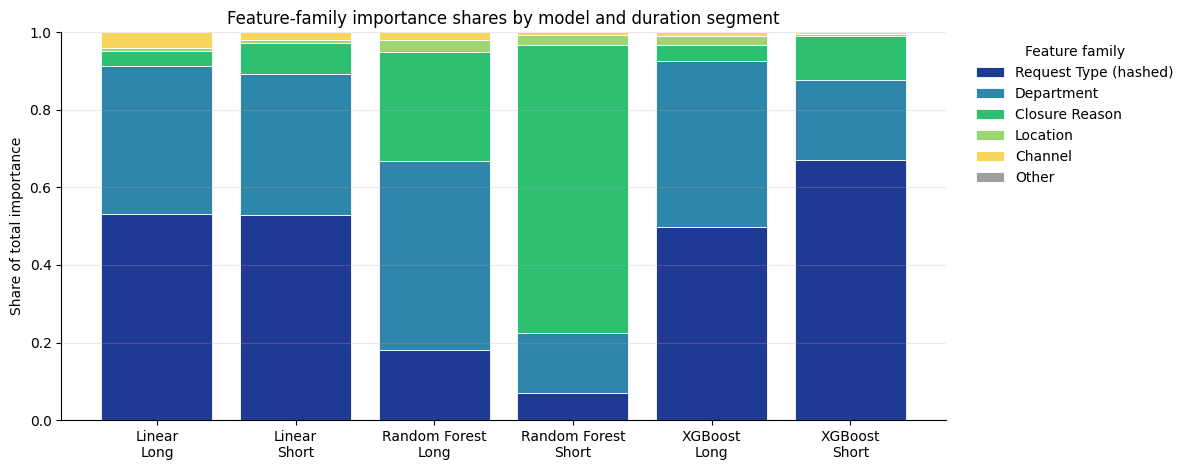

In [ ]:
# Chart 1 (aesthetic upgrade): Stacked bars — Feature-family share (Short vs Long × Model)
# - Uses a viridis-like dark-blue → green → yellow palette (matches your dept heatmap vibe)
# - Straight, aligned x labels (no italics), with newline formatting
# - Cleaner legend + light y-grid

import pandas as pd
import matplotlib.pyplot as plt

# EXPECTED INPUT DFS (already created in your notebook):
# - feature_importance_lr_longshort_group_summary   with cols: Split, group, share
# - feature_importance_xgb_longshort_group_summary  with cols: Split, group, share
# - feature_importance_rf_longshort_group_summary   with cols: Split, group, share

def _shortlong_label(split_str: str) -> str:
    s = str(split_str).lower()
    if "shortlong=short" in s:
        return "Short"
    if "shortlong=long" in s:
        return "Long"
    return str(split_str)

def build_longshort_family_share_df(df_lr, df_xgb, df_rf):
    parts = []
    for model_name, df in [
        ("Linear", df_lr),
        ("XGBoost", df_xgb),
        ("Random Forest", df_rf),
    ]:
        tmp = df.copy()
        tmp["Model"] = model_name
        tmp["Horizon"] = tmp["Split"].apply(_shortlong_label)
        parts.append(tmp[["Model", "Horizon", "group", "share"]])

    out = pd.concat(parts, ignore_index=True)

    group_order = ["Request Type (hashed)", "Department", "Closure Reason", "Location", "Channel", "Other"]
    out["group"] = pd.Categorical(out["group"], categories=group_order, ordered=True)
    out = out.sort_values(["Model", "Horizon", "group"])
    return out

def plot_feature_family_stacked(long_df):
    wide = (
        long_df.pivot_table(index=["Model", "Horizon"], columns="group", values="share", aggfunc="sum")
              .fillna(0.0)
    )

    # consistent order: Linear Long, Linear Short, RF Long, RF Short, XGB Long, XGB Short
    model_order = ["Linear", "Random Forest", "XGBoost"]
    horizon_order = ["Long", "Short"]
    wide = wide.reindex(pd.MultiIndex.from_product([model_order, horizon_order], names=["Model", "Horizon"]))

    wide = wide.reset_index()
    wide["x"] = wide["Model"] + "\n" + wide["Horizon"]  # straight, aligned labels

    groups = [c for c in wide.columns if c not in ["Model", "Horizon", "x"]]
    x = list(range(len(wide)))
    bottom = [0.0] * len(wide)

    # Viridis-like palette (dark blue → green → yellow) to match your heatmap vibe
    color_map = {
        "Request Type (hashed)": "#1f3a93",  # deep blue
        "Department":            "#2e86ab",  # blue
        "Closure Reason":        "#2fbf71",  # green
        "Location":              "#9bd770",  # yellow-green
        "Channel":               "#f6d55c",  # yellow
        "Other":                 "#9e9e9e",  # neutral gray
    }
    colors = [color_map.get(g, None) for g in groups]

    fig, ax = plt.subplots(figsize=(12, 4.8))

    for g, col in zip(groups, colors):
        ax.bar(x, wide[g].values, bottom=bottom, label=g, color=col, edgecolor="white", linewidth=0.6)
        bottom = [b + v for b, v in zip(bottom, wide[g].values)]

    # Axis styling
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Share of total importance")
    ax.set_title("Feature-family importance shares by model and duration segment")

    ax.set_xticks(x)
    ax.set_xticklabels(wide["x"], rotation=0, ha="center")  # straight labels, no italics

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend (compact, outside)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Feature family")

    plt.tight_layout()
    plt.show()

# ---- RUN ----
longshort_share_df = build_longshort_family_share_df(
    feature_importance_lr_longshort_group_summary,
    feature_importance_xgb_longshort_group_summary,
    feature_importance_rf_longshort_group_summary
)
plot_feature_family_stacked(longshort_share_df)

/tmp/ipython-input-2523417725.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(index="Dept", columns="group", values="share", aggfunc="sum")


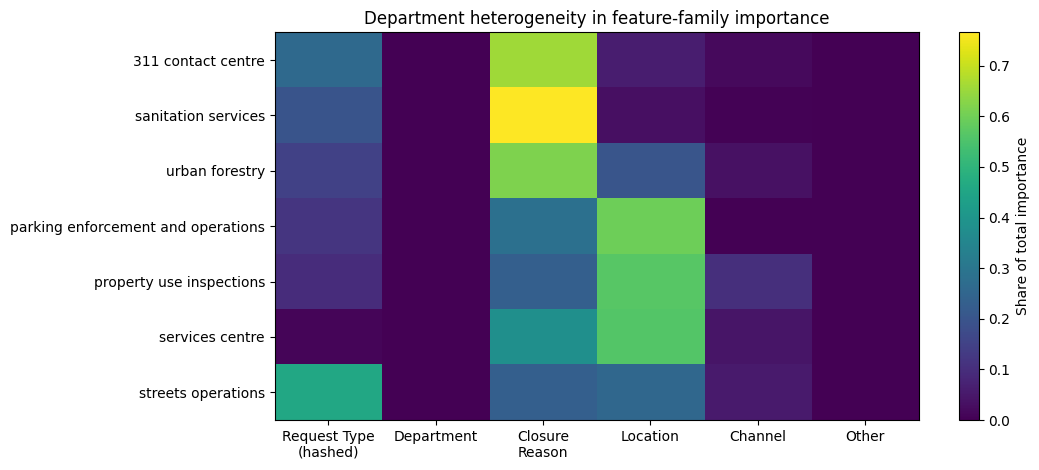

In [ ]:
# Chart 2: Department heatmap — Feature-family share (use XGBoost or RF)
import pandas as pd
import matplotlib.pyplot as plt

# Choose ONE:
dept_family_df = feature_importance_dept_xgb_group_summary  # OR: feature_importance_dept_rf_group_summary

selected_depts = [
    "311 contact centre",
    "sanitation services",
    "urban forestry",
    "parking enforcement and operations",
    "property use inspections",
    "services centre",
    "streets operations",
]

def _dept_name(split_str: str) -> str:
    s = str(split_str)
    if "DeptType=" in s:
        return s.split("DeptType=", 1)[1].strip()
    return s.strip()

def plot_dept_family_heatmap(df, selected_depts):
    tmp = df.copy()
    tmp["Dept"] = tmp["Split"].apply(_dept_name)

    # filter to selected depts
    tmp = tmp[tmp["Dept"].isin(selected_depts)].copy()

    group_order = ["Request Type (hashed)", "Department", "Closure Reason", "Location", "Channel", "Other"]
    tmp["group"] = pd.Categorical(tmp["group"], categories=group_order, ordered=True)

    mat = (
        tmp.pivot_table(index="Dept", columns="group", values="share", aggfunc="sum")
           .reindex(index=selected_depts)
           .fillna(0.0)
    )

    fig, ax = plt.subplots(figsize=(11, 4.8))
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=ax, label="Share of total importance")

    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    wrapped_cols = [
        "Request Type\n(hashed)",
        "Department",
        "Closure\nReason",
        "Location",
        "Channel",
        "Other"
    ]
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(wrapped_cols, rotation=0, ha="center")

    ax.set_title("Department heterogeneity in feature-family importance")
    plt.tight_layout()
    plt.show()

# ---- RUN ----
plot_dept_family_heatmap(dept_family_df, selected_depts)


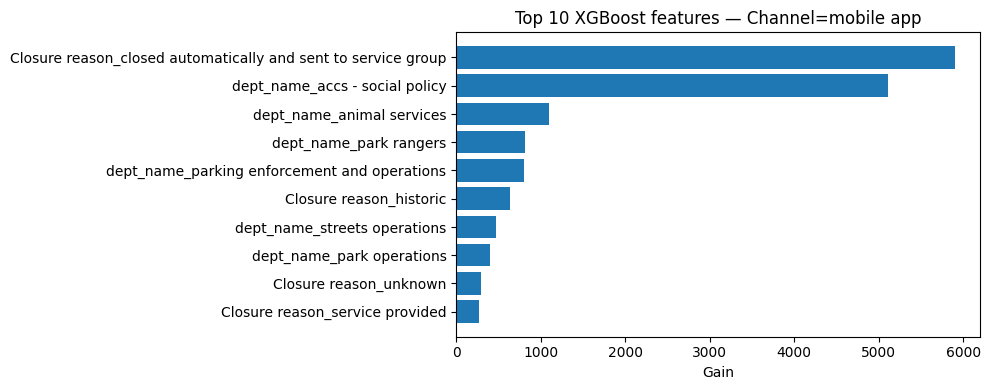

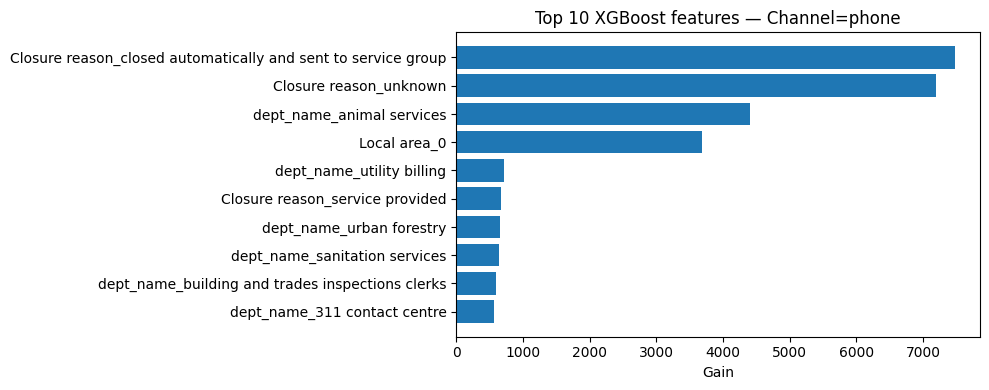

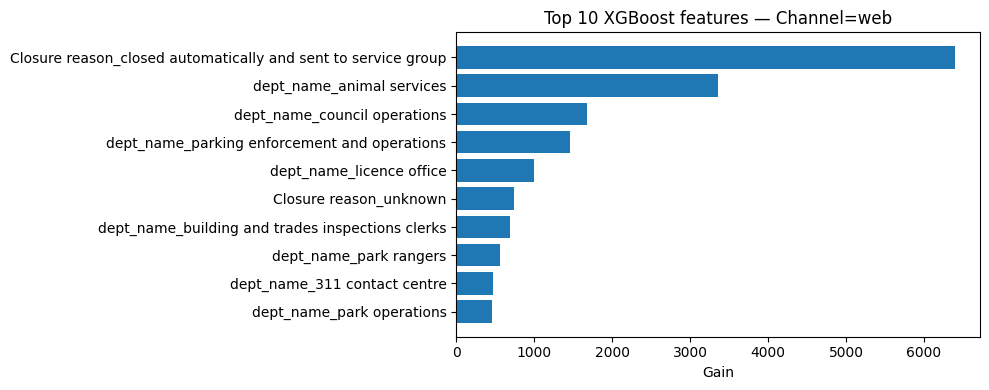

In [ ]:
import matplotlib.pyplot as plt

# Pick ONE:
df_plot = feature_importance_channel_xgb_top10_interpretable   # main report
# df_plot = feature_importance_channel_xgb_top10_overall       # appendix (incl hash)

channels = ["mobile app", "phone", "web"]
k = 10

for ch in channels:
    split = f"Channel={ch}"
    tmp = df_plot[df_plot["Split"] == split].copy()
    if tmp.empty:
        print(f"[WARN] No rows for {split}")
        continue

    tmp = tmp.sort_values("gain", ascending=False).head(k).iloc[::-1]

    plt.figure(figsize=(10, 4))
    plt.barh(tmp["feature"], tmp["gain"])
    plt.title(f"Top {k} XGBoost features — {split}")
    plt.xlabel("Gain")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

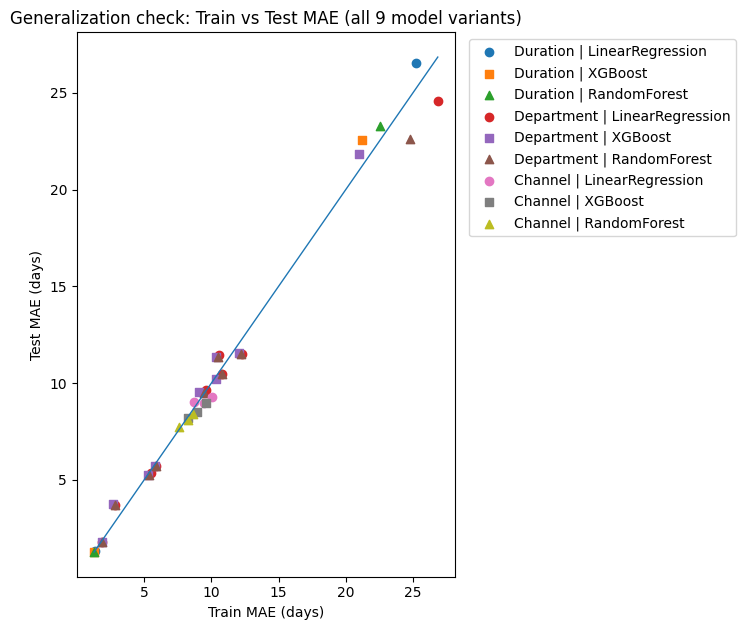

In [ ]:
# Loss performance chart
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Combine ALL perf dfs ----
perf_all = pd.concat(
    [
        perf_lr_longshort, perf_xgb_longshort, perf_rf_longshort,
        perf_dept_lin, perf_dept_xgb, perf_dept_rf,
        perf_channel_lin, perf_channel_xgb, perf_channel_rf
    ],
    ignore_index=True
)

# ---- 2) Ensure MAE_days exists (in case eval_metrics used MAE instead) ----
if "MAE_days" not in perf_all.columns:
    raise KeyError("No 'MAE_days' column found. Check what eval_metrics returns.")

# ---- 3) Label split family from Split string ----
def split_family(split_str: str) -> str:
    s = str(split_str).lower()
    if "shortlong=" in s:
        return "Duration"
    if "depttype=" in s or "dept=" in s:
        return "Department"
    if "channel=" in s:
        return "Channel"
    return "Other"

perf_all["Family"] = perf_all["Split"].apply(split_family)

# ---- 4) Parity table: 1 row per (Split, Model, Family) ----
parity = (
    perf_all.pivot_table(
        index=["Split", "Model", "Family"],
        columns="Dataset",
        values="MAE_days",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"Train": "MAE_train", "Test": "MAE_test"})
)

# ---- 5) Plot: marker = model, color = family ----
fig, ax = plt.subplots(figsize=(7.4, 6.4))

marker_map = {"LinearRegression": "o", "XGBoost": "s", "RandomForest": "^"}

families = [f for f in ["Duration", "Department", "Channel", "Other"] if f in parity["Family"].unique()]

# Plot in layers to keep legend readable
for fam in families:
    fam_df = parity[parity["Family"] == fam]
    for model_name, mk in marker_map.items():
        tmp = fam_df[fam_df["Model"] == model_name]
        if tmp.empty:
            continue
        ax.scatter(tmp["MAE_train"], tmp["MAE_test"], marker=mk, label=f"{fam} | {model_name}")

# Diagonal y=x reference line
mx = max(parity["MAE_train"].max(), parity["MAE_test"].max())
mn = min(parity["MAE_train"].min(), parity["MAE_test"].min())
ax.plot([mn, mx], [mn, mx], linewidth=1)

ax.set_xlabel("Train MAE (days)")
ax.set_ylabel("Test MAE (days)")
ax.set_title("Generalization check: Train vs Test MAE (all 9 model variants)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Quick exploration of LONG-request cases (based on resolution_hours)

DF = df

COL_RES_HRS = "resolution_hours"
COL_DEPT    = "dept_name"
COL_TYPE    = "request_type_norm"
COL_CH      = "Channel"
COL_REASON  = "Closure reason"
COL_AREA    = "Local area"
COL_OPEN    = "Service request open timestamp"
COL_CLOSE   = "Service request close date"

PCTL = 0.75   # your p75 long/short rule
TOPK = 30

df2 = DF.copy()

# numeric + drop missing
df2[COL_RES_HRS] = pd.to_numeric(df2[COL_RES_HRS], errors="coerce")
df2 = df2.dropna(subset=[COL_RES_HRS])

# convert hours -> days for readability
df2["resolution_days"] = df2[COL_RES_HRS] / 24.0

thr_days = df2["resolution_days"].quantile(PCTL)
df2["is_long"] = df2["resolution_days"] > thr_days

print(f"Long threshold (p{int(PCTL*100)}): {thr_days:.2f} days")
print(df2["is_long"].value_counts())

long_df = df2[df2["is_long"]].copy()

# 1) Top longest cases to eyeball
cols_show = [
    "resolution_days", COL_DEPT, COL_TYPE, COL_CH, COL_REASON, COL_AREA,
    COL_OPEN, COL_CLOSE, "Address"
]
cols_show = [c for c in cols_show if c in long_df.columns]

display(long_df.sort_values("resolution_days", ascending=False).head(TOPK)[cols_show])

# 2) Distribution snapshot (long)
display(long_df["resolution_days"].describe(percentiles=[.5,.75,.9,.95,.99]))

# 3) Dept profile within LONG
dept_summary = (
    long_df.groupby(COL_DEPT, dropna=False)
           .agg(
               n_long=("resolution_days", "size"),
               share_long=("resolution_days", lambda s: len(s) / len(long_df)),
               med_days=("resolution_days", "median"),
               mean_days=("resolution_days", "mean"),
               p90_days=("resolution_days", lambda s: np.percentile(s, 90)),
           )
           .sort_values("n_long", ascending=False)
)
display(dept_summary.head(15))

# 4) Request-type profile within LONG
type_summary = (
    long_df.groupby(COL_TYPE, dropna=False)
           .agg(
               n_long=("resolution_days", "size"),
               share_long=("resolution_days", lambda s: len(s) / len(long_df)),
               med_days=("resolution_days", "median"),
               mean_days=("resolution_days", "mean"),
               p90_days=("resolution_days", lambda s: np.percentile(s, 90)),
           )
           .sort_values("n_long", ascending=False)
)
display(type_summary.head(20))

# 5) Channel mix within LONG
ch_summary = (
    long_df.groupby(COL_CH, dropna=False)
           .agg(
               n_long=("resolution_days", "size"),
               share_long=("resolution_days", lambda s: len(s) / len(long_df)),
               med_days=("resolution_days", "median"),
           )
           .sort_values("n_long", ascending=False)
)
display(ch_summary)

# 6) Over-index: LONG share vs overall share (dept + type)
def overindex_table(df_all, df_long, key_col, top_n=15):
    overall = df_all[key_col].value_counts(dropna=False)
    longc = df_long[key_col].value_counts(dropna=False)

    out = pd.DataFrame({
        "n_all": overall,
        "share_all": overall / len(df_all),
        "n_long": longc,
        "share_long": longc / len(df_long),
    }).fillna(0)

    out["over_index"] = np.where(out["share_all"] > 0, out["share_long"] / out["share_all"], np.nan)
    out = out.sort_values("over_index", ascending=False)
    return out.head(top_n)

display(overindex_table(df2, long_df, COL_DEPT, top_n=15))
display(overindex_table(df2, long_df, COL_TYPE, top_n=20))

# 7) High-impact combos: Dept × Type (top long counts)
combo = (
    long_df.groupby([COL_DEPT, COL_TYPE], dropna=False)
           .agg(n_long=("resolution_days", "size"), med_days=("resolution_days", "median"))
           .sort_values("n_long", ascending=False)
)
display(combo.head(25))

# 8) Dept × Closure reason (often explains “routing/administrative” patterns)
dept_reason = (
    long_df.groupby([COL_DEPT, COL_REASON], dropna=False)
           .agg(n_long=("resolution_days", "size"), med_days=("resolution_days", "median"))
           .sort_values("n_long", ascending=False)
)
display(dept_reason.head(25))

Long threshold (p75): 7.78 days
is_long
False    149982
True      49994
Name: count, dtype: int64


,resolution_days,dept_name,request_type_norm,Channel,Closure reason,Local area,Service request open timestamp,Service request close date,Address
11652,1218.630243,urban forestry,city and park trees maintenance case,phone,service provided,Killarney,2022-08-17T18:23:00-07:00,2025-12-18,3486 KINGSWAY
11029,1217.826771,urban forestry,city and park trees maintenance case,mobile app,service provided,Mount Pleasant,2022-08-18T13:40:00-07:00,2025-12-18,2600 to 2600 PRINCE EDWARD ST
117589,1217.710104,urban forestry,city and park trees maintenance case,mobile app,service provided,Hastings-Sunrise,2022-08-18T16:28:00-07:00,2025-12-18,3484 E HASTINGS ST
39859,1209.834120,urban forestry,city and park trees maintenance case,web,service provided,0,2022-08-26T13:29:25-07:00,2025-12-18,2000 W GEORGIA ST
101247,1209.630278,urban forestry,city and park trees maintenance case,e-mail,service provided,Riley Park,2022-08-26T18:22:58-07:00,2025-12-18,3200 to 3200 MANITOBA ST
150226,1206.973241,urban forestry,city and park trees maintenance case,phone,service provided,West End,2022-08-29T10:09:06-07:00,2025-12-18,1110 CARDERO ST
51539,1206.972488,urban forestry,city and park trees maintenance case,phone,service provided,Victoria-Fraserview,2022-08-29T10:10:11-07:00,2025-12-18,2069 E 49TH AV
161891,1206.888542,urban forestry,city and park trees maintenance case,web,service provided,0,2022-08-29T12:11:04-07:00,2025-12-18,0
170417,1201.944838,urban forestry,city and park trees maintenance case,mobile app,service provided,West End,2022-09-03T10:50:00-07:00,2025-12-18,1066 HARWOOD ST
186481,1201.753866,urban forestry,city and park trees maintenance case,phone,service provided,Arbutus Ridge,2022-09-03T15:25:00-07:00,2025-12-18,2292 W 37TH AV


,resolution_days
count,49994.000000
mean,37.172674
std,90.787727
min,7.782292
50%,14.656574
75%,25.981921
90%,58.499806
95%,117.993743
99%,534.289515
max,1218.630243


,n_long,share_long,med_days,mean_days,p90_days
dept_name,,,,,
sanitation services,13838,0.276793,13.517882,21.939444,32.710530
services centre,7288,0.145777,12.239554,16.315905,23.037154
licence office,5521,0.110433,20.022627,27.262440,49.970810
streets operations,3776,0.075529,13.700799,32.126753,69.940260
urban forestry,2807,0.056147,21.936458,113.313773,490.443356
311 contact centre,1911,0.038225,20.910359,63.327292,150.156875
traffic and electrical operations and design,1861,0.037224,18.403924,42.297192,76.381169
parking enforcement and operations,1610,0.032204,15.760694,19.499916,32.271506
business and election services,1487,0.029744,12.231447,23.749964,40.428183


,n_long,share_long,med_days,mean_days,p90_days
request_type_norm,,,,,
building and development inquiry case,7261,0.145237,12.251586,16.327607,23.055347
business licence request case,5446,0.108933,19.988189,27.138804,49.917668
garbage bin request case,3527,0.070548,15.892141,19.571581,28.985019
green bin request case,3281,0.065628,12.902627,16.128355,23.839028
city and park trees maintenance case,2695,0.053906,21.027859,110.026505,494.314812
mayor and council feedback case,1478,0.029564,12.235938,23.821154,40.926832
abandoned non-recyclables-small case,1432,0.028643,13.581701,41.100913,91.009773
abandoned or uninsured vehicle case,1394,0.027883,15.971042,20.056028,33.638163
missed green bin pickup case,1382,0.027643,12.150943,14.522060,21.152868


,n_long,share_long,med_days
Channel,,,
web,25479,0.509641,14.105289
phone,16617,0.332380,14.990984
mobile app,7197,0.143957,14.722488
chat,301,0.006021,16.962014
e-mail,212,0.004241,26.497020
social media,133,0.002660,19.175035
unknown,41,0.000820,12.789641
mail,12,0.000240,19.493368
mail out,2,0.000040,230.996238


,n_all,share_all,n_long,share_long,over_index
dept_name,,,,,
streets furniture,897,0.004486,717,0.014342,3.197324
transit integrations and projects,23,0.000115,14,0.00028,2.434783
streets horticulture,210,0.00105,127,0.00254,2.419048
transportation design,178,0.00089,104,0.00208,2.337079
community transportation branch,336,0.00168,189,0.00378,2.250000
transportation planning,80,0.0004,45,0.0009,2.250000
neighbourhood energy branch,9,0.000045,5,0.0001,2.222222
development and major projects branch,321,0.001605,173,0.00346,2.155763
traffic and data management,2009,0.010046,1001,0.020022,1.993031


,n_all,share_all,n_long,share_long,over_index
request_type_norm,,,,,
neighbourhood energy utility issue case,2,0.00001,2,0.00004,4.000000
street furniture litter can maintenance case,16,0.00008,15,0.0003,3.750000
street furniture maintenance case,712,0.00356,620,0.012401,3.483146
business support request case,57,0.000285,49,0.00098,3.438596
z - curb ramp request case,6,0.00003,5,0.0001,3.333333
commercial street curbside sign request case,87,0.000435,69,0.00138,3.172414
parking meter request case,32,0.00016,25,0.0005,3.125000
school traffic concern case,61,0.000305,47,0.00094,3.081967
streets horticulture program inquiry case,73,0.000365,56,0.00112,3.068493


n_long  \
dept_name                                    request_type_norm                                     
services centre                              building and development inquiry case          7261   
licence office                               business licence request case                  5446   
sanitation services                          garbage bin request case                       3527   
                                             green bin request case                         3281   
urban forestry                               city and park trees maintenance case           2695   
business and election services               mayor and council feedback case                1478   
sanitation services                          abandoned non-recyclables-small case           1432   
parking enforcement and operations           abandoned or uninsured vehicle case            1394   
sanitation services                          missed green bin pickup case                   1382   
traffic and electrical operations and design street light out case                          1200   
311 contact centre                           city services feedback case                    1129   
streets operations                           pothole case                                   1085   
sanitation services                          abandoned mattress case                        1045   
                                             missed garbage bin pickup case                  875   
integrated graffiti management               graffiti removal - city property case           673   
sanitation services                          abandoned recyclables case                      653   
311 contact centre                           general feedback case                           621   
streets furniture                            street furniture maintenance case               620   
streets operations                           street surface water flooding case              610   
                                             street repair case                              592   
waterworks operations                        water leak case                                 527   
streets operations                           zz old - urban issues on city property case     503   
corporate services                           parks feedback case                             483   
streets operations                           sidewalk repair case                            458   
park operations                              parks operations and maintenance case           455   

                                                                                            med_days  
dept_name                                    request_type_norm                                        
services centre                              building and development inquiry case         12.251586  
licence office                               business licence request case                 19.988189  
sanitation services                          garbage bin request case                      15.892141  
                                             green bin request case                        12.902627  
urban forestry                               city and park trees maintenance case          21.027859  
business and election services               mayor and council feedback case               12.235938  
sanitation services                          abandoned non-recyclables-small case          13.581701  
parking enforcement and operations           abandoned or uninsured vehicle case           15.971042  
sanitation services                          missed green bin pickup case                  12.150943  
traffic and electrical operations and design street light out case                         18.531424  
311 contact centre                           city services feedback case                   19.203935  
streets operations                           potho

,,n_long,med_days
dept_name,Closure reason,,
sanitation services,service provided,11696,13.657778
services centre,service provided,6676,12.176262
licence office,service provided,3763,22.109850
urban forestry,further action has been planned,2437,18.809097
streets operations,service provided,2423,13.163380
parking enforcement and operations,service provided,1559,15.681042
traffic and electrical operations and design,service provided,1382,17.004855
waterworks operations,service provided,1244,12.932020
business and election services,service provided,1191,12.598449
